# Imports

In [ ]:
import os
import json
import joblib
import warnings
import optuna
from optuna.samplers import TPESampler

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from xgboost import XGBRegressor

from scipy import stats
from scipy.stats import pearsonr

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
OUTPUT_DIR = "./output_grouped"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.style.use("default")
sns.set_theme(style="whitegrid")


# 1. Data Loading

In [ ]:
data = pd.read_csv(
    "calix_database_full.csv",
    sep=";",
    encoding="cp1251",
    decimal=","
)

print("Dataset shape:", data.shape)
data.head()


Dataset shape: (266, 27)


,Folder,File,Program Version,SMILES,Atoms_1,Atoms_2,Atoms_3,Atoms_4,dihedral_1_orca,dihedral_2_orca,...,Magnitude (Debye),Dipole_xtb (Debye),Final Energy (Eh),Total energy xtb (Eh),HOMO_orca (eV),LUMO_orca (eV),HOMO-LUMO Gap (eV),HOMO_xtb (eV),LUMO_xtb (eV),HOMO-LUMO xtb (eV)
0,Group 1,1.log,6.0.0,OC1=C(CC2=C(C(CC3=C(O)C(CC4=CC(C(C)(C)C)=CC(CC...,28-12-14-15,21-22-24-25,43-3-5-41,35-7-9-34,-0.308,0.498,...,2.590703366,2.478,-2007.777943398343,-139.177613,-6.030502,-0.610805,5.419776172200001,-9.9169,-6.0708,3.846091
1,Group 1,2.log,6.0.0,OC1=C(CC2=C(C(CC3=C(O)C(CC4=CC(Br)=CC(CC1=C5)=...,32-5-3-34,22-21-19-18,15-14-12-25,28-9-7-29,0.137,-0.620,...,3.535005031,10.409,-11671.72278906903,-102.835983,-6.500109,-1.218862,5.281324569000001,-10.8366,-7.3075,3.529071
2,Group 1,3.log,6.0.0,OC1=C(CC2=CC(C(C)(C)C)=CC3=C2O)C=C(C(C)(C)C)C=...,22-23-25-96,98-28-30-31,37-38-40-41,47-48-50-51,1.669,162.334,...,0.07467472,0.028,-4015.554962182609,-278.371600,-5.954284,-0.580329,5.3740338088,-9.8131,-5.9846,3.828526
3,Group 1,4.log,6.0.0,OC1=C(SC2=C(C(SC3=C(O)C(SC4=CC(C(C)(C)C)=CC(SC...,25-24-22-21,15-14-12-28,34-9-7-35,41-5-3-43,-3.282,3.904,...,6.794153481,8.595,-3442.525320095948,-139.464044,-6.460735,-1.185202,5.275610175000001,-9.8855,-7.0091,2.876384
4,Group 1,5.log,6.0.0,OC1=C(SC2=C(C(SC3=C(O)C(S4)=CC=C3)=CC=C2)O)C=C...,17-7-9-16,14-12-29-30,32-26-24-23,21-3-5-19,-7.535,7.358,...,5.052353374,6.307,-2814.661638889585,-88.794873,-6.772791,-1.283951,5.4889203396,-10.1069,-7.2734,2.833483


In [3]:
print(data.dtypes)

Folder                    object
File                      object
Program Version           object
SMILES                    object
Atoms_1                   object
Atoms_2                   object
Atoms_3                   object
Atoms_4                   object
dihedral_1_orca          float64
dihedral_2_orca          float64
dihedral_3_orca          float64
dihedral_4_orca          float64
dihedral_1_xtb           float64
dihedral_2_xtb           float64
dihedral_3_xtb           float64
dihedral_4_xtb           float64
Number of Atoms            int64
Magnitude (Debye)         object
Dipole_xtb (Debye)       float64
Final Energy (Eh)         object
Total energy xtb (Eh)    float64
HOMO_orca (eV)           float64
LUMO_orca (eV)           float64
HOMO-LUMO Gap (eV)        object
HOMO_xtb (eV)            float64
LUMO_xtb (eV)            float64
HOMO-LUMO xtb (eV)       float64
dtype: object


## 1.1 Numeric conversion

In [4]:

numeric_cols = [
    "dihedral_1_orca",
    "dihedral_2_orca",
    "dihedral_3_orca",
    "dihedral_4_orca",
    "dihedral_1_xtb",
    "dihedral_2_xtb",
    "dihedral_3_xtb",
    "dihedral_4_xtb",
    "Number of Atoms",
    "Magnitude (Debye)",
    "Dipole_xtb (Debye)",
    "Final Energy (Eh)",
    "Total energy xtb (Eh)",
    "HOMO_orca (eV)",
    "LUMO_orca (eV)",
    "HOMO-LUMO Gap (eV)",
    "HOMO_xtb (eV)",
    "LUMO_xtb (eV)",
    "HOMO-LUMO xtb (eV)",
]

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

missing_summary = data[numeric_cols].isna().sum().sort_values(ascending=False)
print(missing_summary[missing_summary > 0])

data[data[numeric_cols].isna().any(axis=1)].head()


dihedral_1_orca    15
dihedral_3_orca    15
dihedral_4_orca    15
dihedral_1_xtb     15
dihedral_2_xtb     15
dihedral_3_xtb     15
dihedral_4_xtb     15
dihedral_2_orca    15
dtype: int64


,Folder,File,Program Version,SMILES,Atoms_1,Atoms_2,Atoms_3,Atoms_4,dihedral_1_orca,dihedral_2_orca,...,Magnitude (Debye),Dipole_xtb (Debye),Final Energy (Eh),Total energy xtb (Eh),HOMO_orca (eV),LUMO_orca (eV),HOMO-LUMO Gap (eV),HOMO_xtb (eV),LUMO_xtb (eV),HOMO-LUMO xtb (eV)
75,Group 7,72.log,6.0.0,OC(C=C1)=CC=C1/N=N/C2=CC=C([N+]([O-])=O)C=C2,NaN,NaN,NaN,NaN,NaN,NaN,...,7.199178,11.289,-850.946504,-51.096075,-6.699321,-2.911332,3.788045,-9.8632,-9.0211,0.842072
76,Group 7,73.log,6.0.0,OCCCOC(C=C1)=CC=C1/N=N/C2=CC=C([N+]([O-])=O)C=C2,NaN,NaN,NaN,NaN,NaN,NaN,...,7.178044,11.346,-1043.736047,-64.642234,-6.632055,-2.889727,3.742384,-9.8054,-8.9571,0.848376
77,Group 7,74.log,6.0.0,CCCCCCCCOC(C=C1)=CC=C1/N=N/C2=CC=C([N+]([O-])=...,NaN,NaN,NaN,NaN,NaN,NaN,...,8.183655,12.713,-1164.858230,-76.409827,-6.581987,-2.856937,3.725105,-9.7315,-8.9131,0.818400
78,Group 7,75.log,6.0.0,OCCN(CC)C(C=C1)=CC=C1/N=N/C2=CC=C([N+]([O-])=O...,NaN,NaN,NaN,NaN,NaN,NaN,...,9.143029,14.413,-1063.148583,-67.186200,-5.985930,-2.711222,3.274756,-9.4801,-8.6633,0.816793
112,Group 9,109.log,6.0.0,CC(C)(C)C(C=C1)=CC=C1OCC2=N3N([H][N]4C(COC5=CC...,NaN,NaN,NaN,NaN,NaN,NaN,...,2.149567,2.000,-3832.915063,-255.867585,-5.876433,-0.957637,4.918869,-9.9602,-6.9416,3.018645


## 1.2 Feature engineering

In [5]:
dihedral_cols = [
    "dihedral_1_xtb",
    "dihedral_2_xtb",
    "dihedral_3_xtb",
    "dihedral_4_xtb",
]

for col in dihedral_cols:
    # флаг наличия угла оставляем
    data[col + "_exists"] = data[col].notna().astype(int)

    # сначала считаем sin/cos только там, где угол есть
    angle_rad = np.deg2rad(data[col])
    data[col + "_sin"] = np.sin(angle_rad)
    data[col + "_cos"] = np.cos(angle_rad)

    # для строк, где угла нет, явно ставим sin=0, cos=1
    missing_mask = data[col].isna()
    data.loc[missing_mask, col + "_sin"] = 0.0
    data.loc[missing_mask, col + "_cos"] = 1.0

data["delta_homo"] = data["HOMO_orca (eV)"] - data["HOMO_xtb (eV)"]
data["delta_lumo"] = data["LUMO_orca (eV)"] - data["LUMO_xtb (eV)"]
data["delta_energy_per_atom"] = (data["Final Energy (Eh)"] - data["Total energy xtb (Eh)"]) / data["Number of Atoms"]
data["delta_energy"] = data["Final Energy (Eh)"] - data["Total energy xtb (Eh)"]

# Additional informative descriptors derived from xTB outputs
data["energy_xtb_per_atom"] = data["Total energy xtb (Eh)"] / data["Number of Atoms"]
data["dipole_xtb_per_atom"] = data["Dipole_xtb (Debye)"] / data["Number of Atoms"]
data["abs_homo_xtb"] = data["HOMO_xtb (eV)"].abs()
data["abs_lumo_xtb"] = data["LUMO_xtb (eV)"].abs()

data[[
    "delta_homo",
    "delta_lumo",
    "delta_energy",
    "delta_energy_per_atom",
    "energy_xtb_per_atom",
    "dipole_xtb_per_atom"
]].describe()


,delta_homo,delta_lumo,delta_energy,delta_energy_per_atom,energy_xtb_per_atom,dipole_xtb_per_atom
count,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000
mean,3.753667,5.907977,-6339.120999,-38.999071,-1.492937,0.041591
std,0.230893,0.327768,4666.476705,32.819084,0.184029,0.052638
min,2.898414,2.832077,-18720.762656,-270.903247,-2.437544,0.000000
25%,3.664076,5.804900,-6800.328313,-33.901479,-1.504880,0.011109
50%,3.771150,5.912046,-4680.758154,-31.112182,-1.452315,0.026224
75%,3.867521,6.001739,-3661.285771,-24.717196,-1.414164,0.052722
max,5.428766,6.831011,-765.674339,-17.080677,-1.267910,0.418111


# 2. Exploratory Data Analysis (EDA)

## 2.1 95% confidence intervals for targets

In [6]:

target_cols = ["delta_homo", "delta_lumo", "delta_energy_per_atom", "delta_energy"]

metrics = {}

for feature in target_cols:
    mean = data[feature].mean()
    std_dev = data[feature].std()
    n = len(data)
    std_error = std_dev / np.sqrt(n)
    z_score = stats.norm.ppf(0.975)
    margin_of_error = z_score * std_error

    metrics[feature] = {
        "mean": mean,
        "std": std_dev,
        "95% CI Lower": mean - margin_of_error,
        "95% CI Upper": mean + margin_of_error,
        "95% CI Width": 2 * margin_of_error
    }

ci_df = pd.DataFrame(metrics).T
ci_df


,mean,std,95% CI Lower,95% CI Upper,95% CI Width
delta_homo,3.753667,0.230893,3.725920,3.781414,0.055494
delta_lumo,5.907977,0.327768,5.868588,5.947366,0.078778
delta_energy_per_atom,-38.999071,32.819084,-42.943042,-35.055100,7.887942
delta_energy,-6339.120999,4666.476705,-6899.905982,-5778.336017,1121.569965


## 2.2 Baseline xTB vs ORCA correlations

In [7]:

print("HOMO baseline correlation")
print(data[["HOMO_xtb (eV)", "HOMO_orca (eV)"]].corr())
print()
print("LUMO baseline correlation")
print(data[["LUMO_xtb (eV)", "LUMO_orca (eV)"]].corr())
print()
print("Final energy baseline correlation")
print(data[["Total energy xtb (Eh)", "Final Energy (Eh)"]].corr())


HOMO baseline correlation
                HOMO_xtb (eV)  HOMO_orca (eV)
HOMO_xtb (eV)        1.000000        0.841695
HOMO_orca (eV)       0.841695        1.000000

LUMO baseline correlation
                LUMO_xtb (eV)  LUMO_orca (eV)
LUMO_xtb (eV)        1.000000        0.906789
LUMO_orca (eV)       0.906789        1.000000

Final energy baseline correlation
                       Total energy xtb (Eh)  Final Energy (Eh)
Total energy xtb (Eh)               1.000000           0.819918
Final Energy (Eh)                   0.819918           1.000000


## 2.3 Scatter plots of xTB features vs target deltas

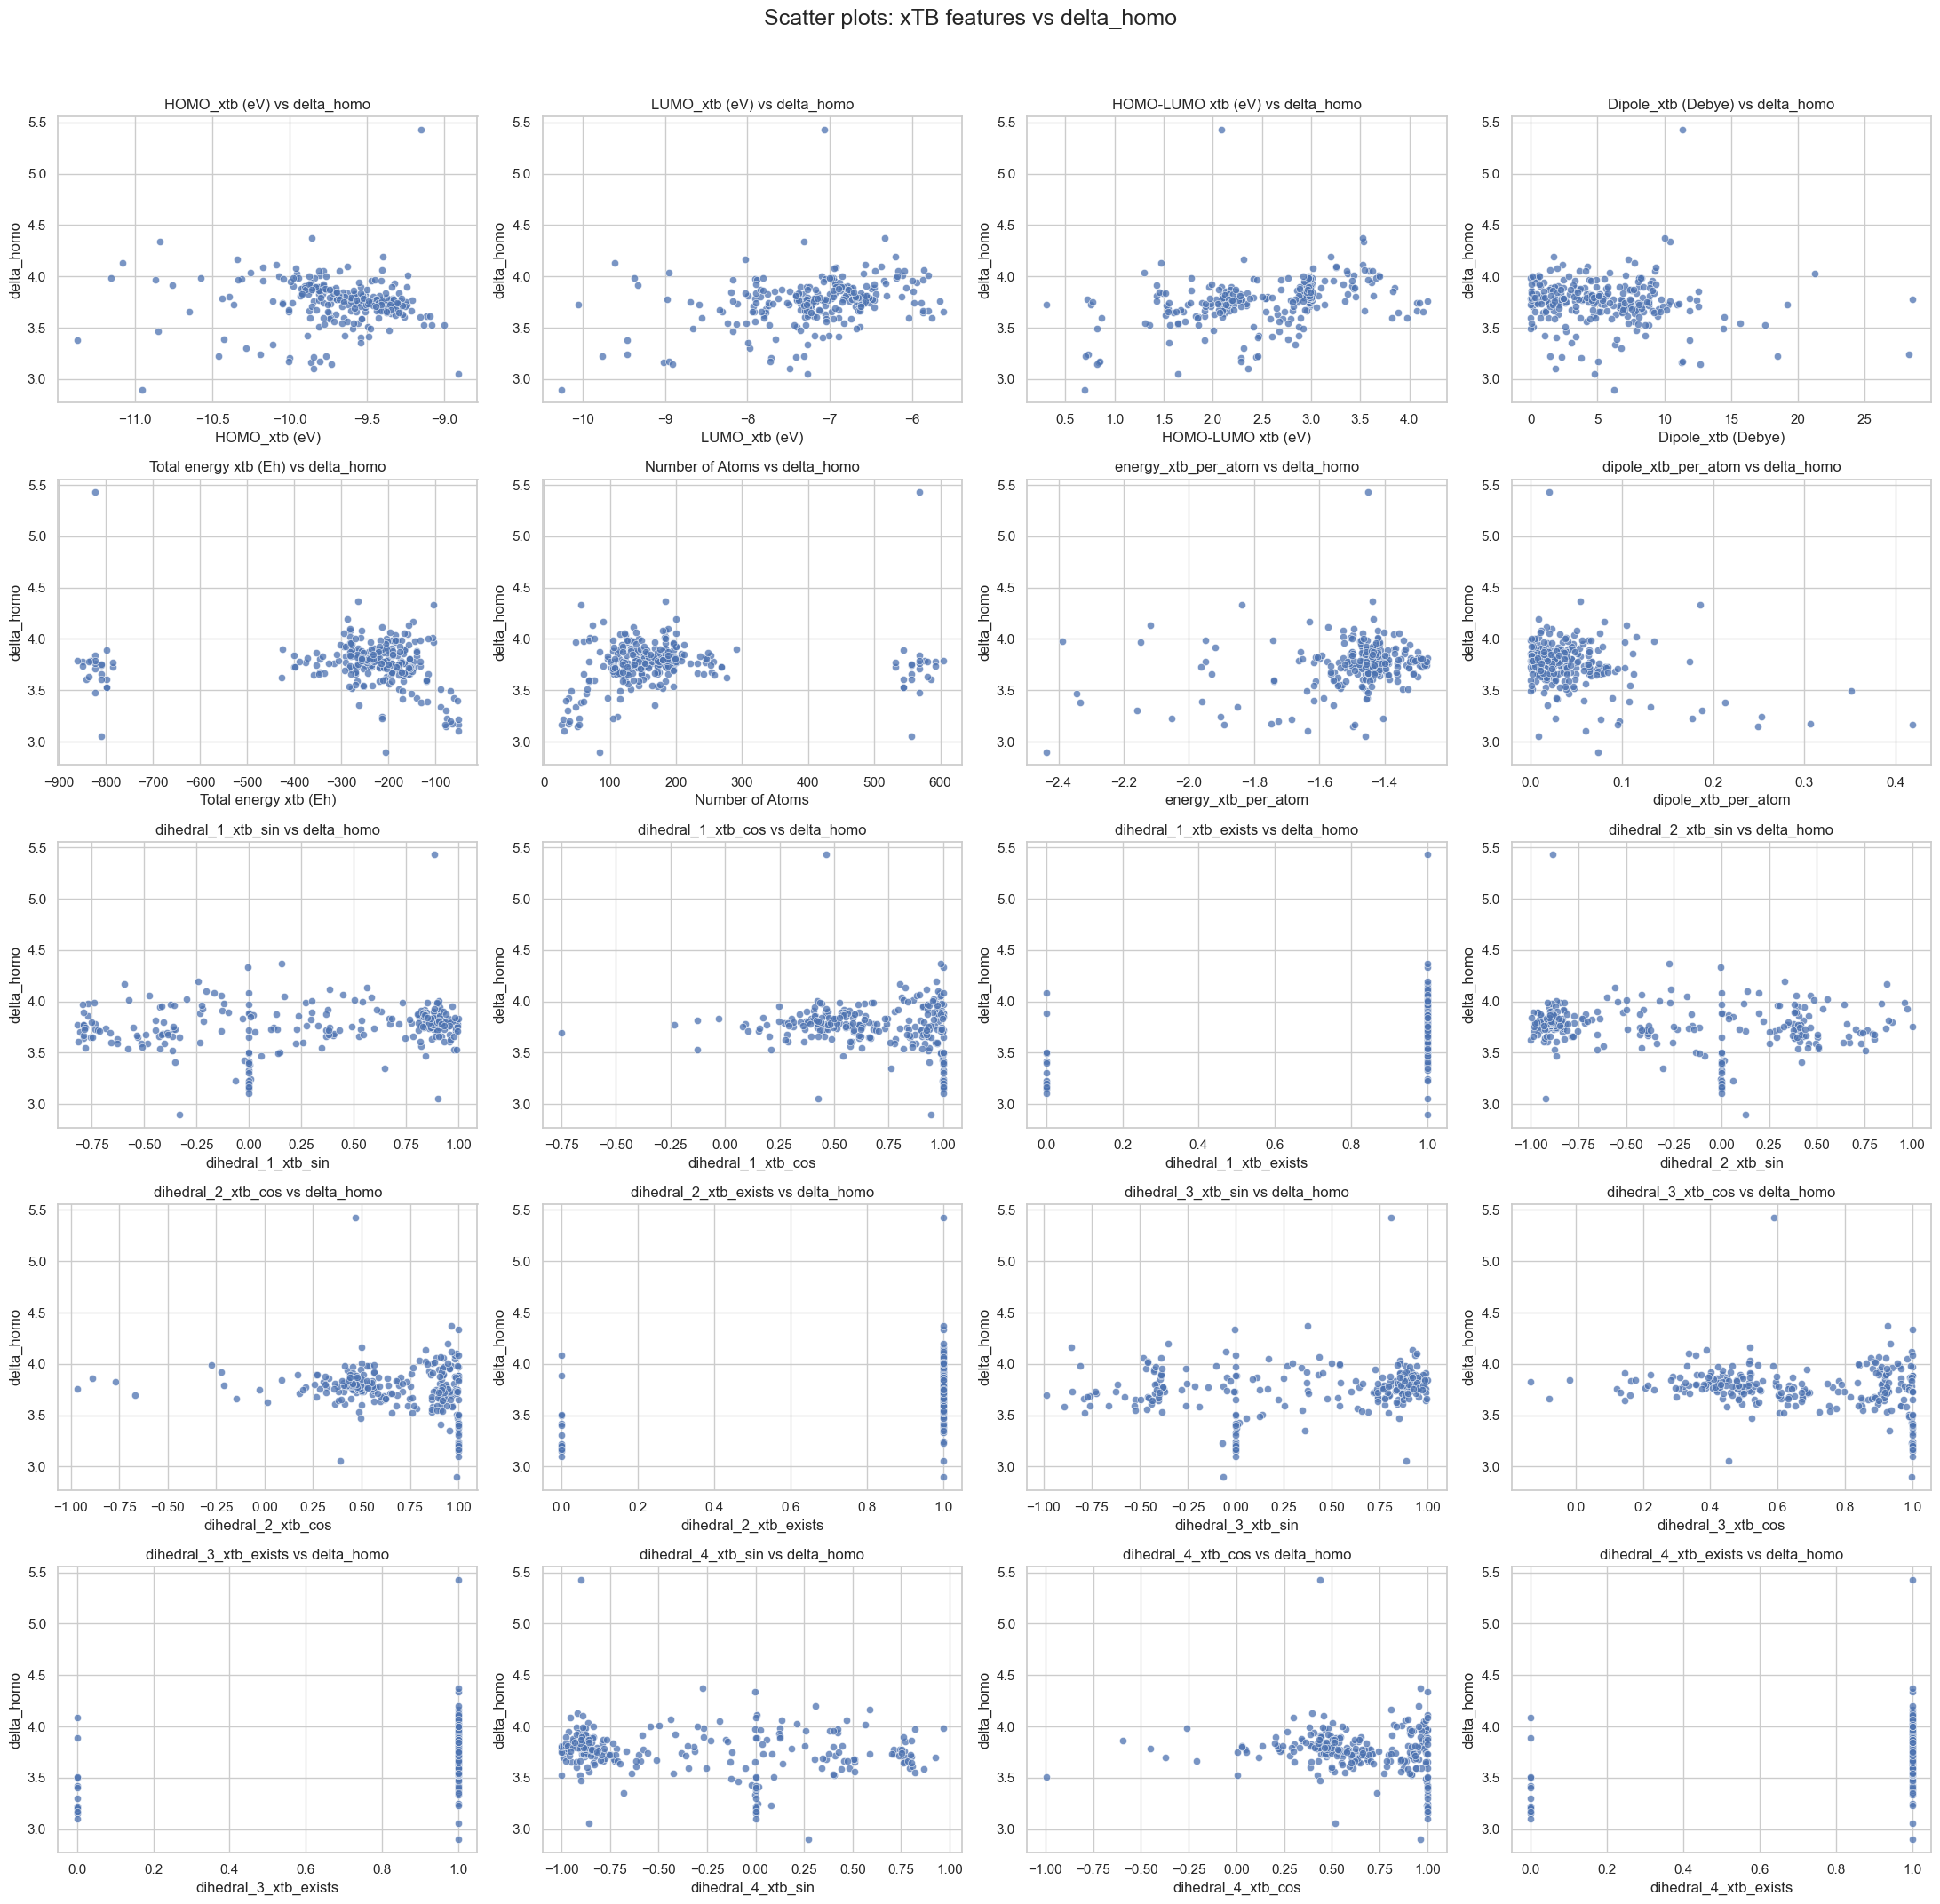

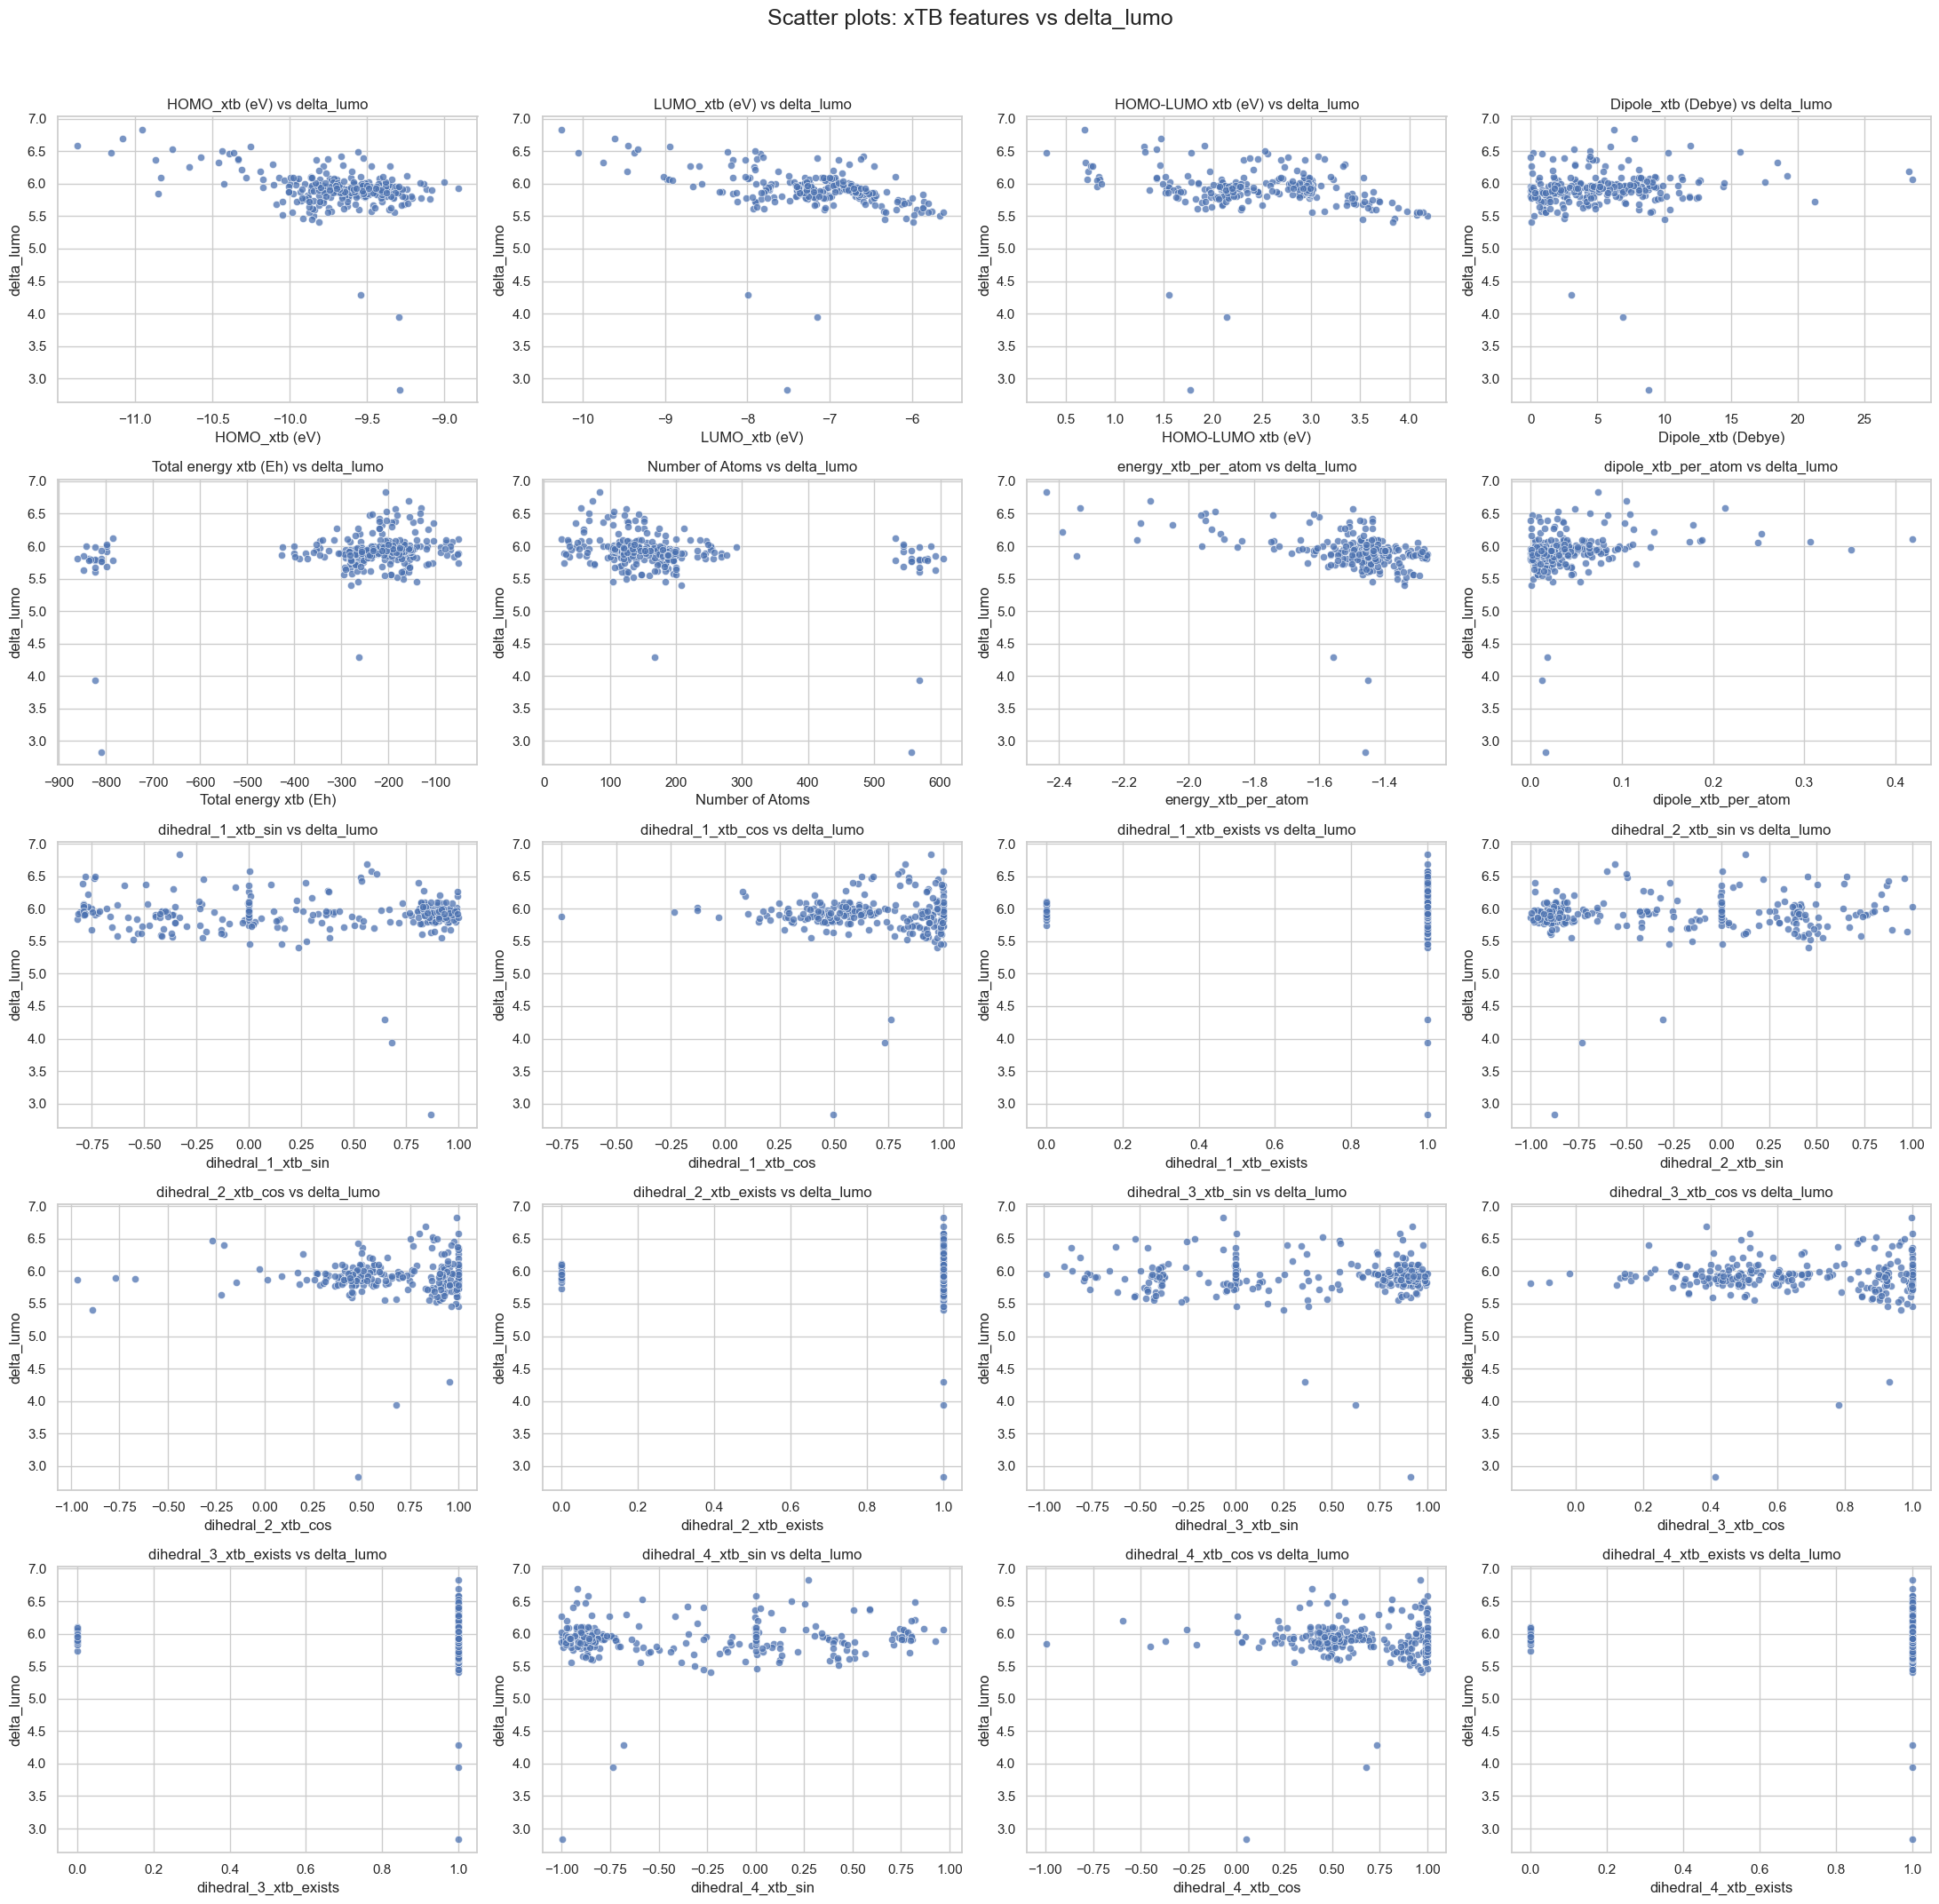

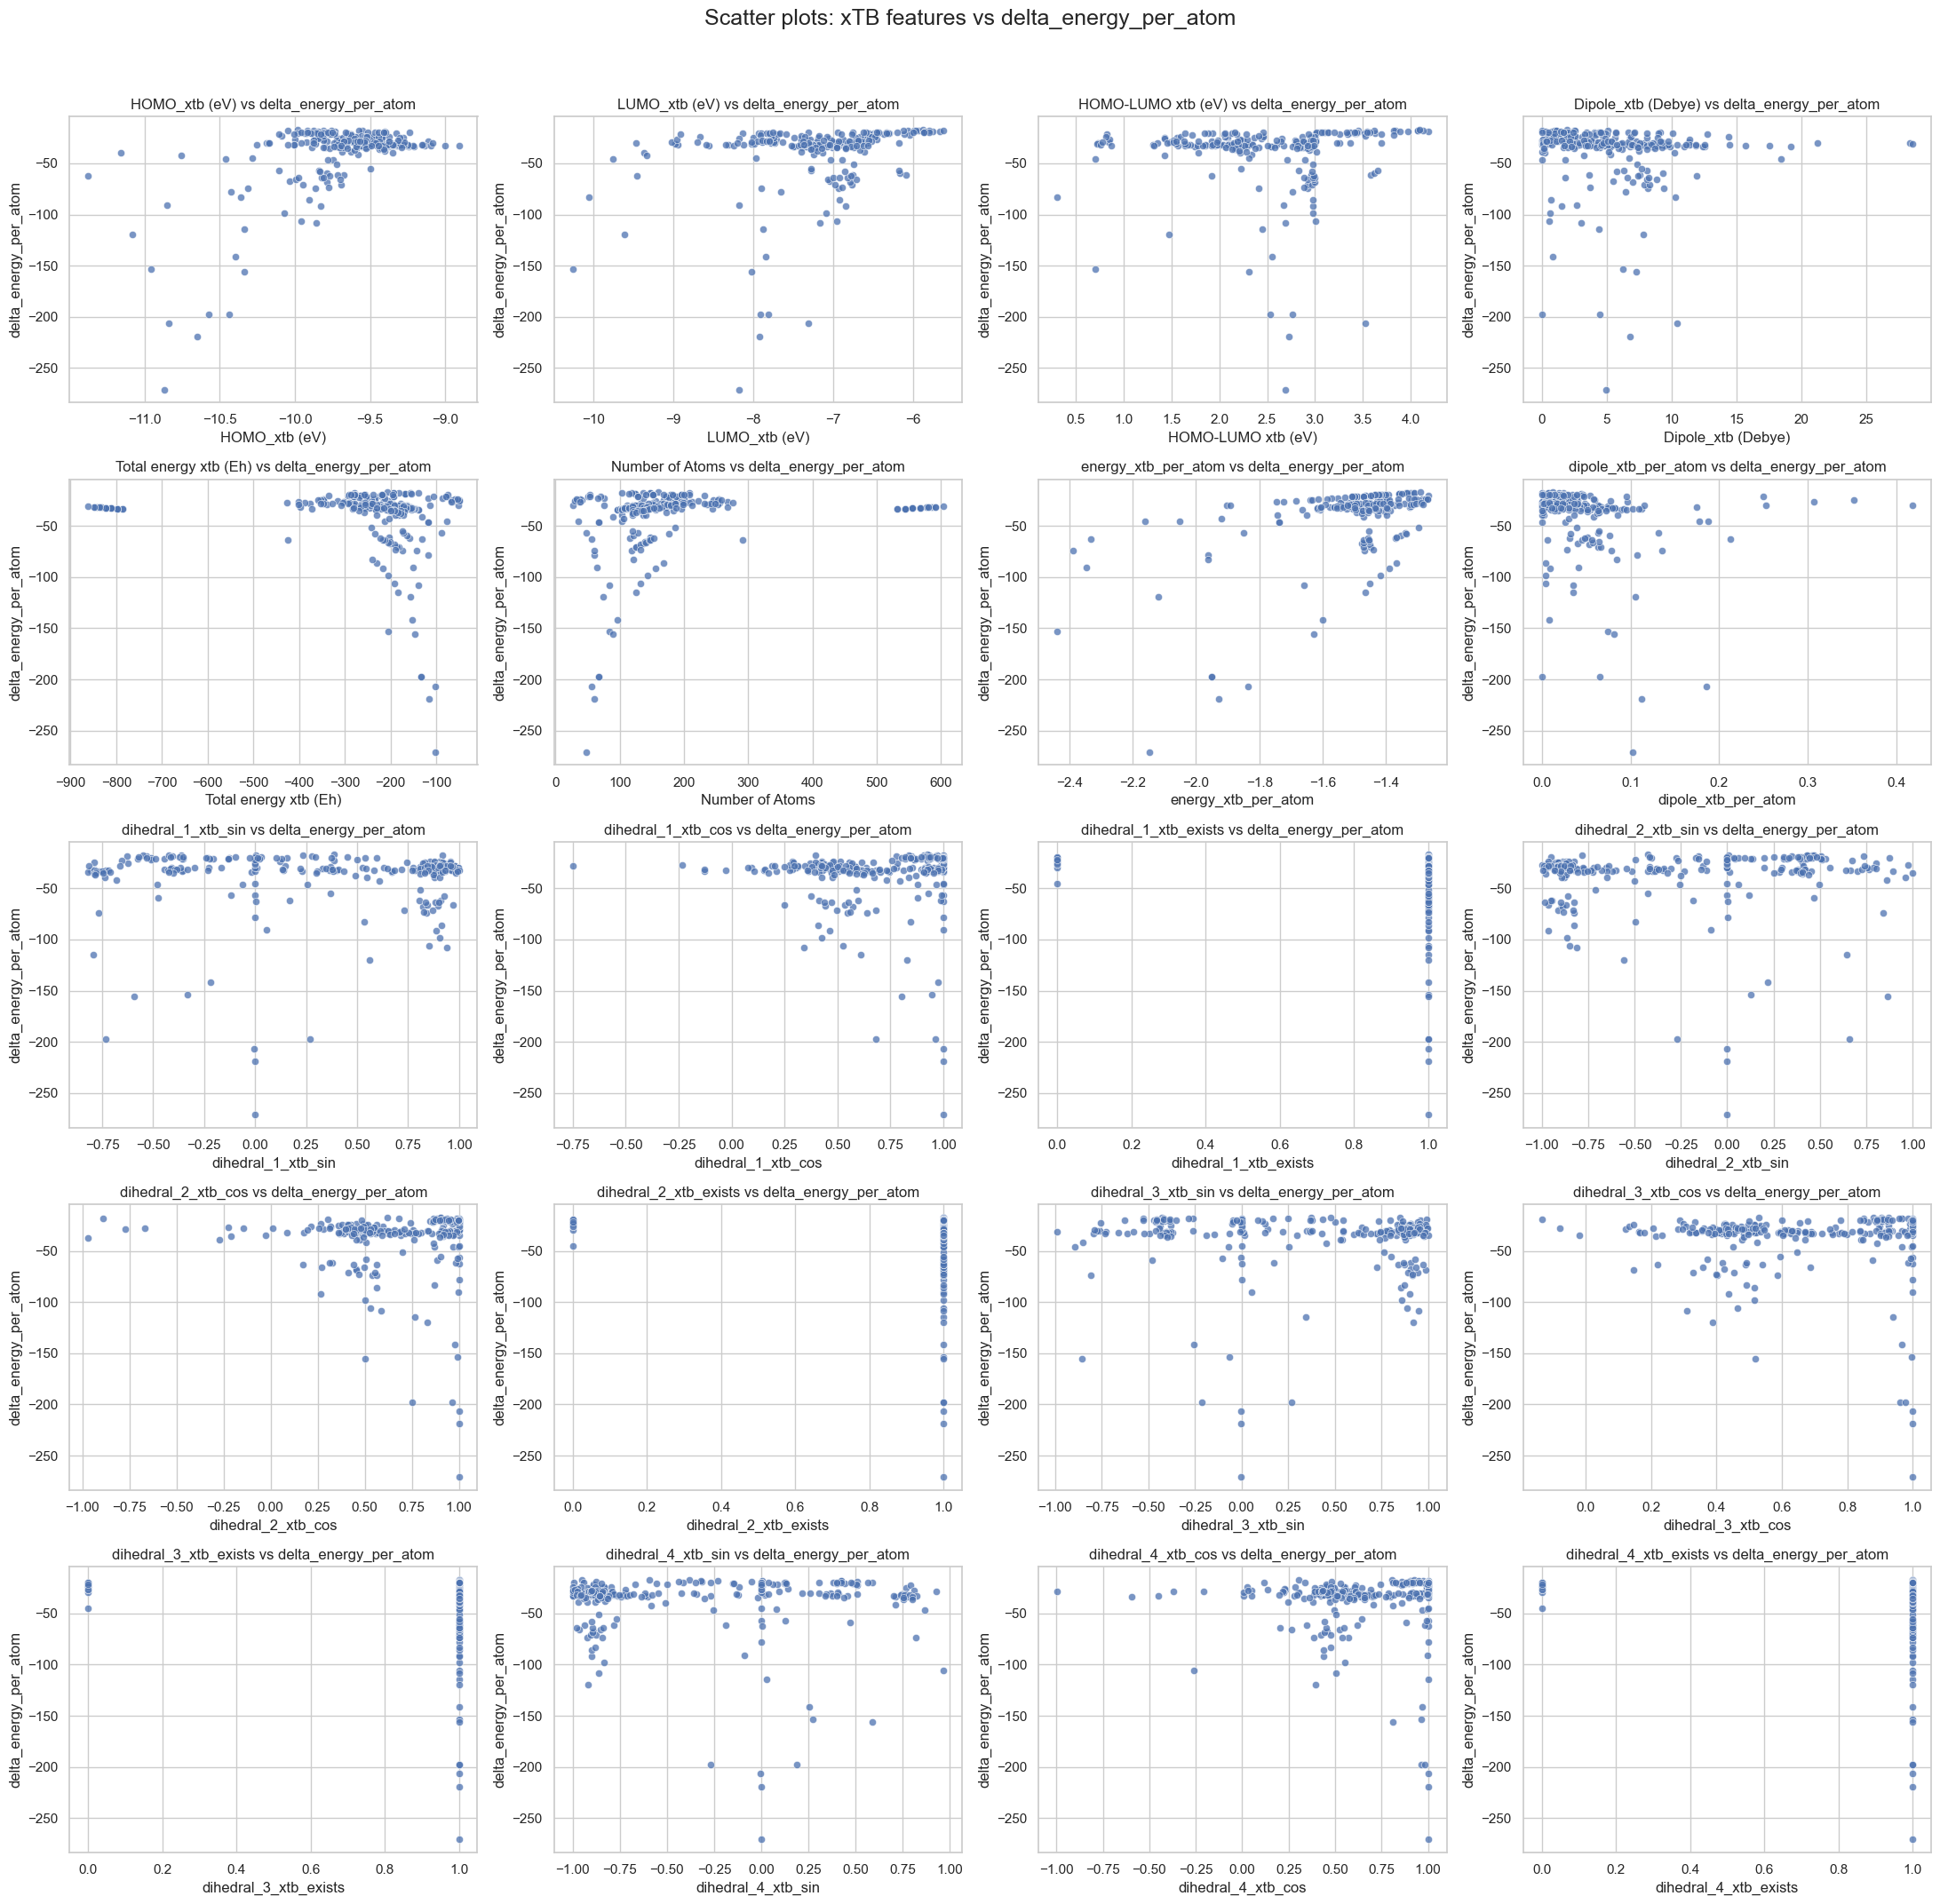

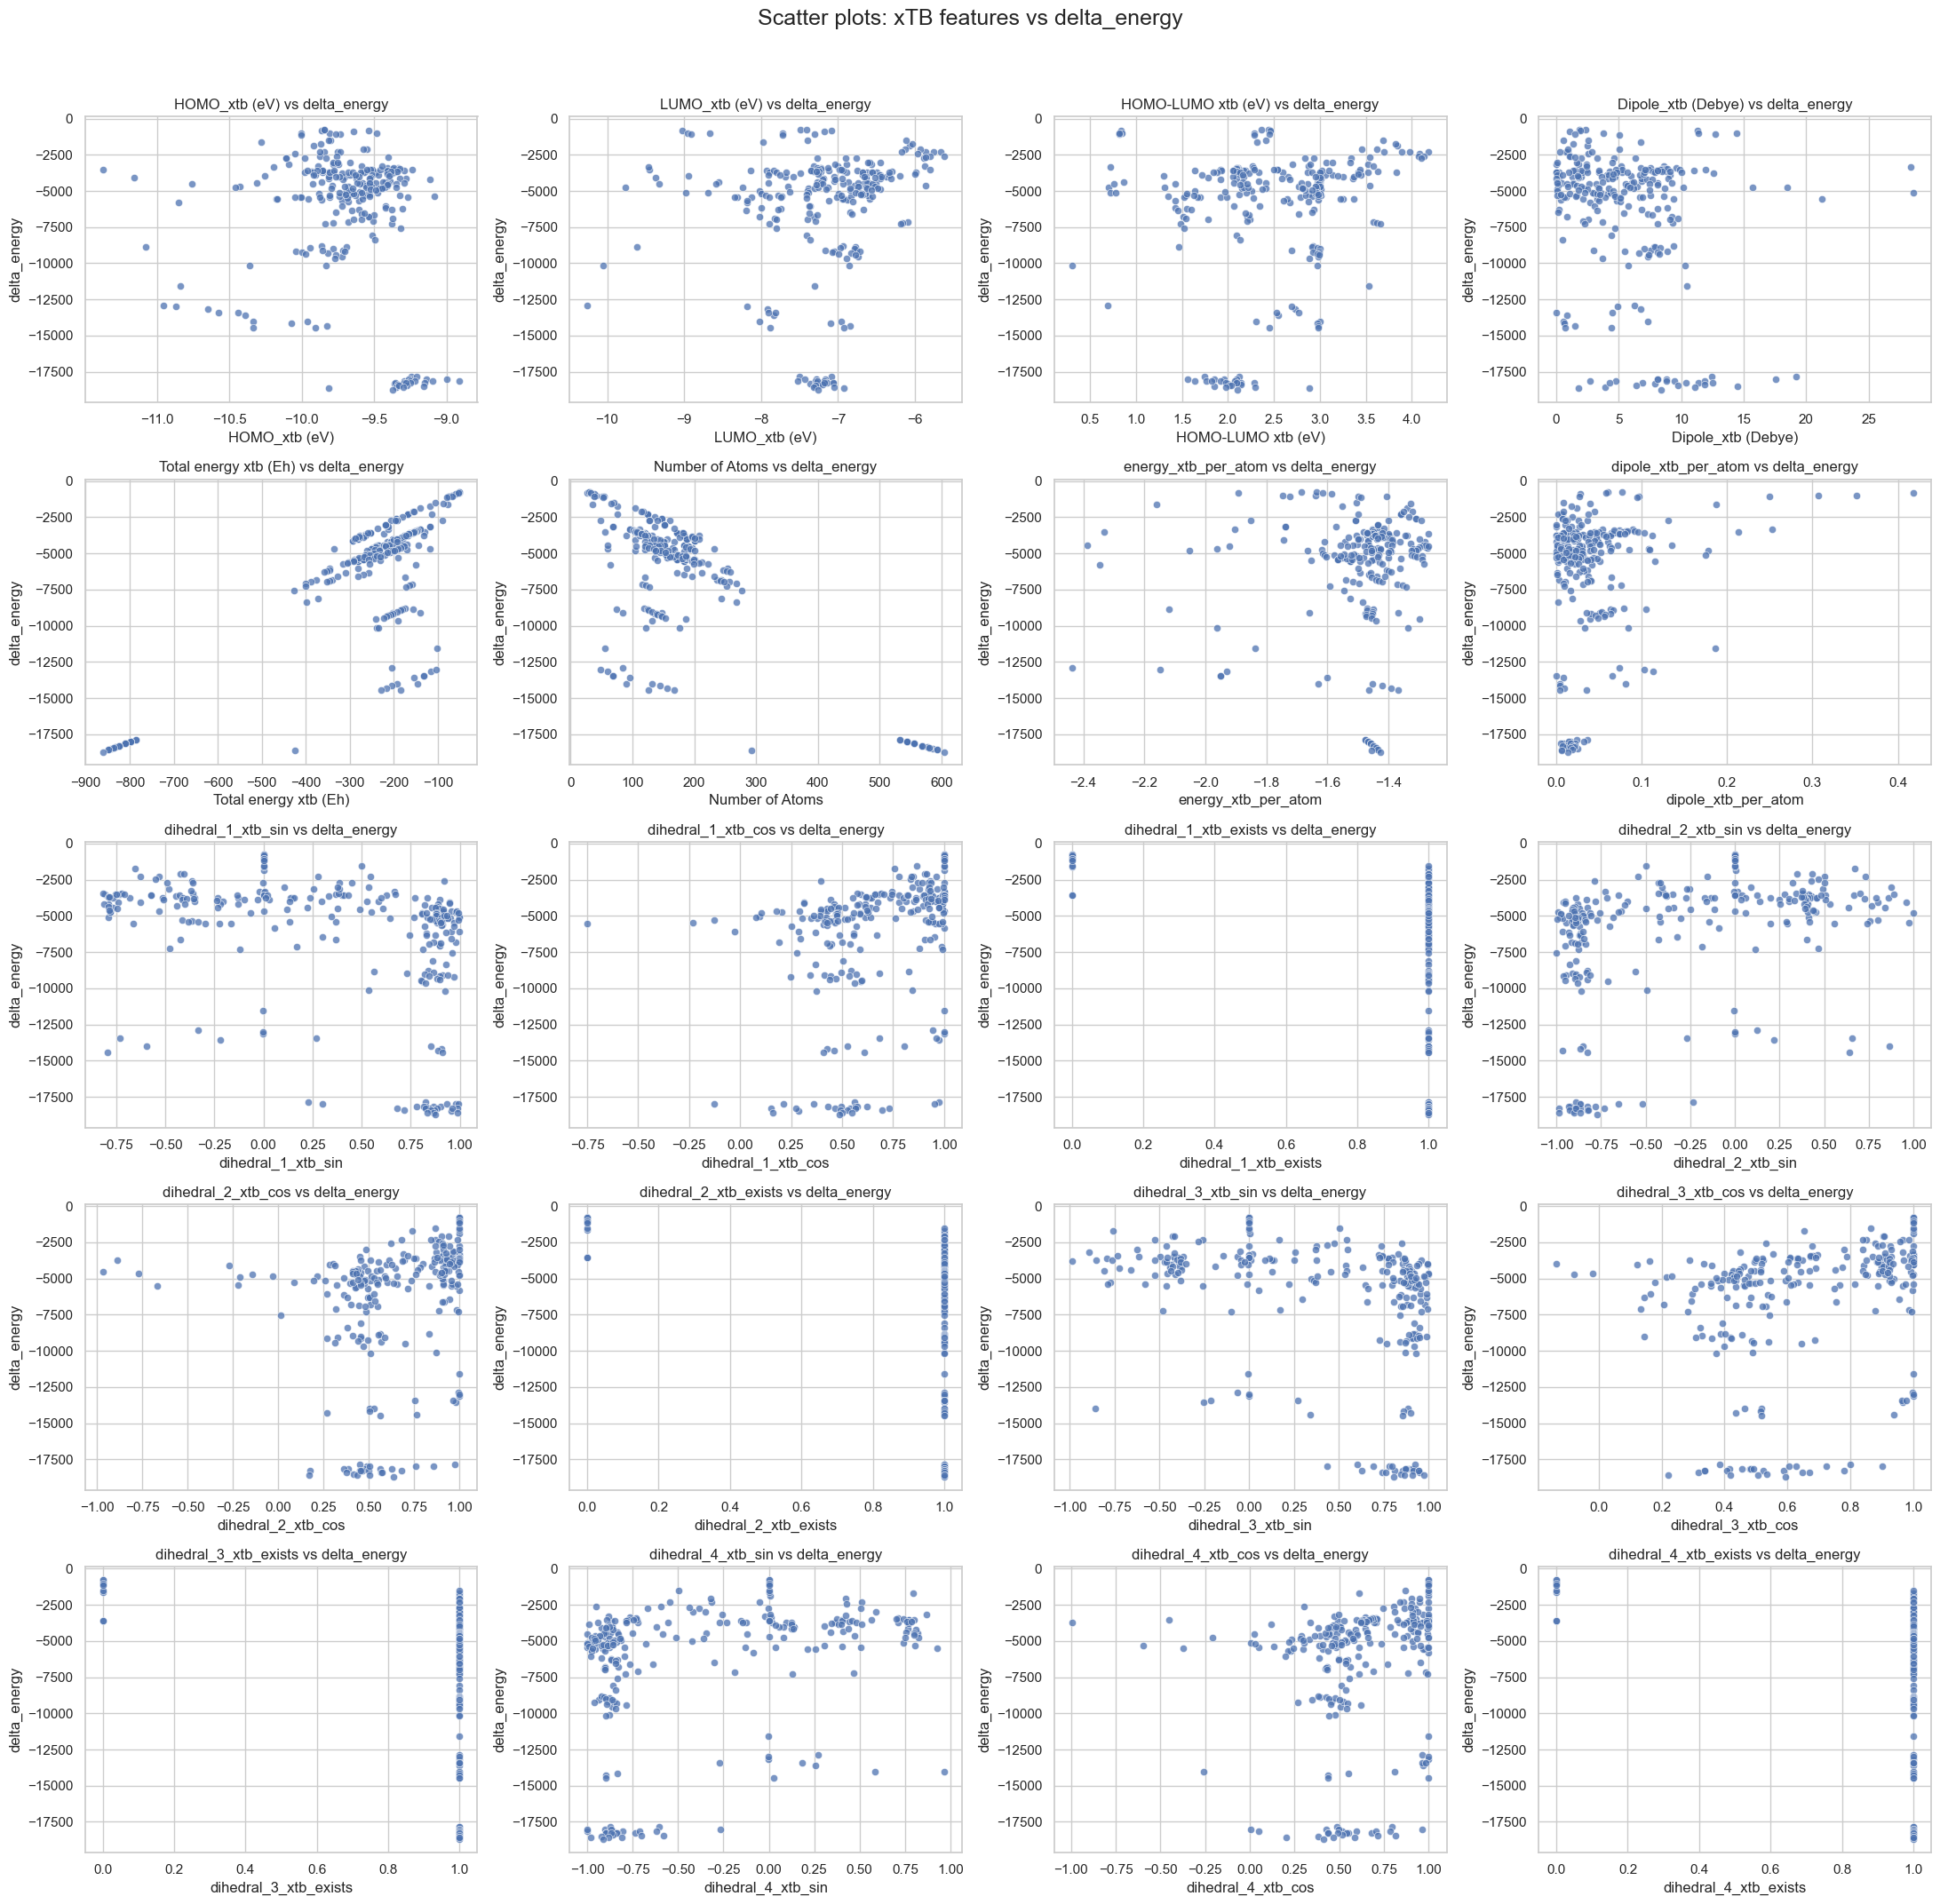

In [8]:

xtb_features_eda = [
    "HOMO_xtb (eV)",
    "LUMO_xtb (eV)",
    "HOMO-LUMO xtb (eV)",
    "Dipole_xtb (Debye)",
    "Total energy xtb (Eh)",
    "Number of Atoms",
    "energy_xtb_per_atom",
    "dipole_xtb_per_atom",
    "dihedral_1_xtb_sin",
    "dihedral_1_xtb_cos",
    "dihedral_1_xtb_exists",
    "dihedral_2_xtb_sin",
    "dihedral_2_xtb_cos",
    "dihedral_2_xtb_exists",
    "dihedral_3_xtb_sin",
    "dihedral_3_xtb_cos",
    "dihedral_3_xtb_exists",
    "dihedral_4_xtb_sin",
    "dihedral_4_xtb_cos",
    "dihedral_4_xtb_exists",
]

targets_eda = ["delta_homo", "delta_lumo", "delta_energy_per_atom", "delta_energy"]

for target in targets_eda:
    n_cols = 4
    n_rows = int(np.ceil(len(xtb_features_eda) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4.2 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, feature in enumerate(xtb_features_eda):
        sns.scatterplot(data=data, x=feature, y=target, ax=axes[i], s=35, alpha=0.75)
        axes[i].set_title(f"{feature} vs {target}")

    for j in range(len(xtb_features_eda), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Scatter plots: xTB features vs {target}", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()


## 2.4 Correlation matrix between xTB features and target deltas

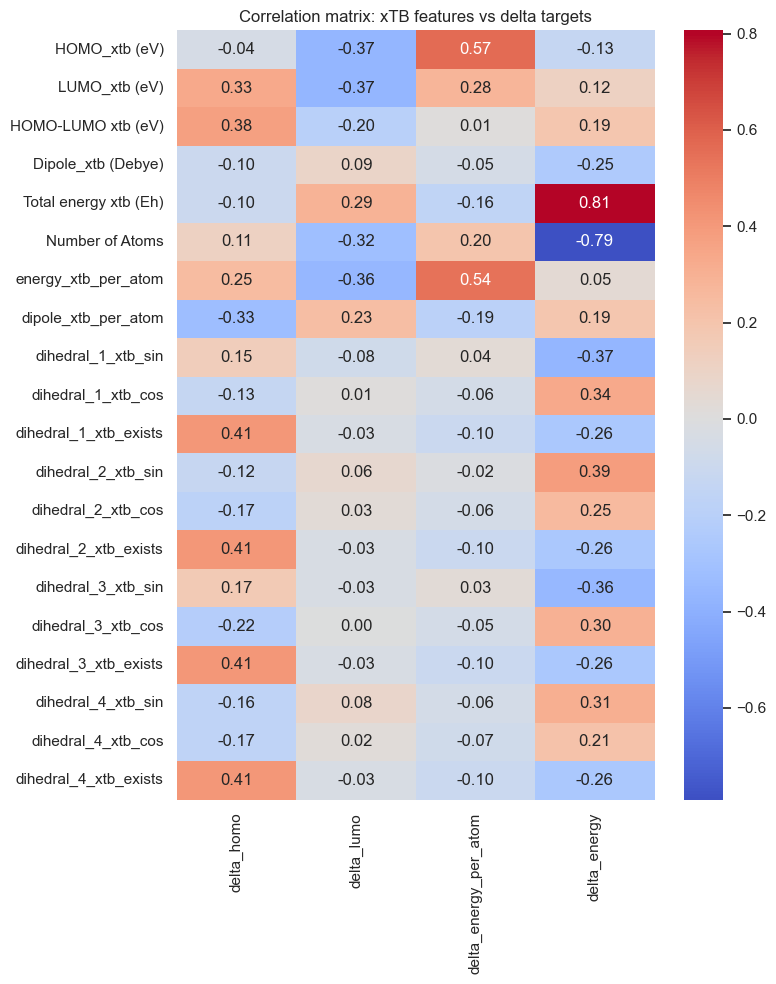

,delta_homo,delta_lumo,delta_energy_per_atom,delta_energy
HOMO_xtb (eV),-0.044466,-0.368632,0.566124,-0.131012
LUMO_xtb (eV),0.334275,-0.368347,0.279020,0.117361
HOMO-LUMO xtb (eV),0.375950,-0.203803,0.009804,0.190156
Dipole_xtb (Debye),-0.102560,0.093421,-0.048387,-0.246473
Total energy xtb (Eh),-0.098010,0.290067,-0.160118,0.806567
Number of Atoms,0.114369,-0.316234,0.196496,-0.790080
energy_xtb_per_atom,0.249785,-0.360125,0.539001,0.045161
dipole_xtb_per_atom,-0.326651,0.233503,-0.190725,0.193772
dihedral_1_xtb_sin,0.145003,-0.077679,0.036388,-0.372003
dihedral_1_xtb_cos,-0.134985,0.008782,-0.058875,0.338563


In [9]:

correlation_matrix = data[xtb_features_eda + targets_eda].corr().loc[xtb_features_eda, targets_eda]
plt.figure(figsize=(8, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation matrix: xTB features vs delta targets")
plt.tight_layout()
plt.show()

correlation_matrix


## 2.5 Ranked correlations

In [10]:

average_correlations = correlation_matrix.abs().mean(axis=1).sort_values(ascending=False)
max_correlations = correlation_matrix.abs().max(axis=1).sort_values(ascending=False)

print("Average absolute correlation")
display(average_correlations.to_frame("avg_abs_corr"))

print("Maximum absolute correlation")
display(max_correlations.to_frame("max_abs_corr"))


Average absolute correlation


,avg_abs_corr
Number of Atoms,0.354295
Total energy xtb (Eh),0.338690
energy_xtb_per_atom,0.298518
HOMO_xtb (eV),0.277558
LUMO_xtb (eV),0.274751
dipole_xtb_per_atom,0.236163
dihedral_3_xtb_exists,0.202415
dihedral_2_xtb_exists,0.202415
dihedral_1_xtb_exists,0.202415
dihedral_4_xtb_exists,0.202415


Maximum absolute correlation


,max_abs_corr
Total energy xtb (Eh),0.806567
Number of Atoms,0.790080
HOMO_xtb (eV),0.566124
energy_xtb_per_atom,0.539001
dihedral_3_xtb_exists,0.410992
dihedral_2_xtb_exists,0.410992
dihedral_1_xtb_exists,0.410992
dihedral_4_xtb_exists,0.410992
dihedral_2_xtb_sin,0.388623
HOMO-LUMO xtb (eV),0.375950


## 2.6 Distributions

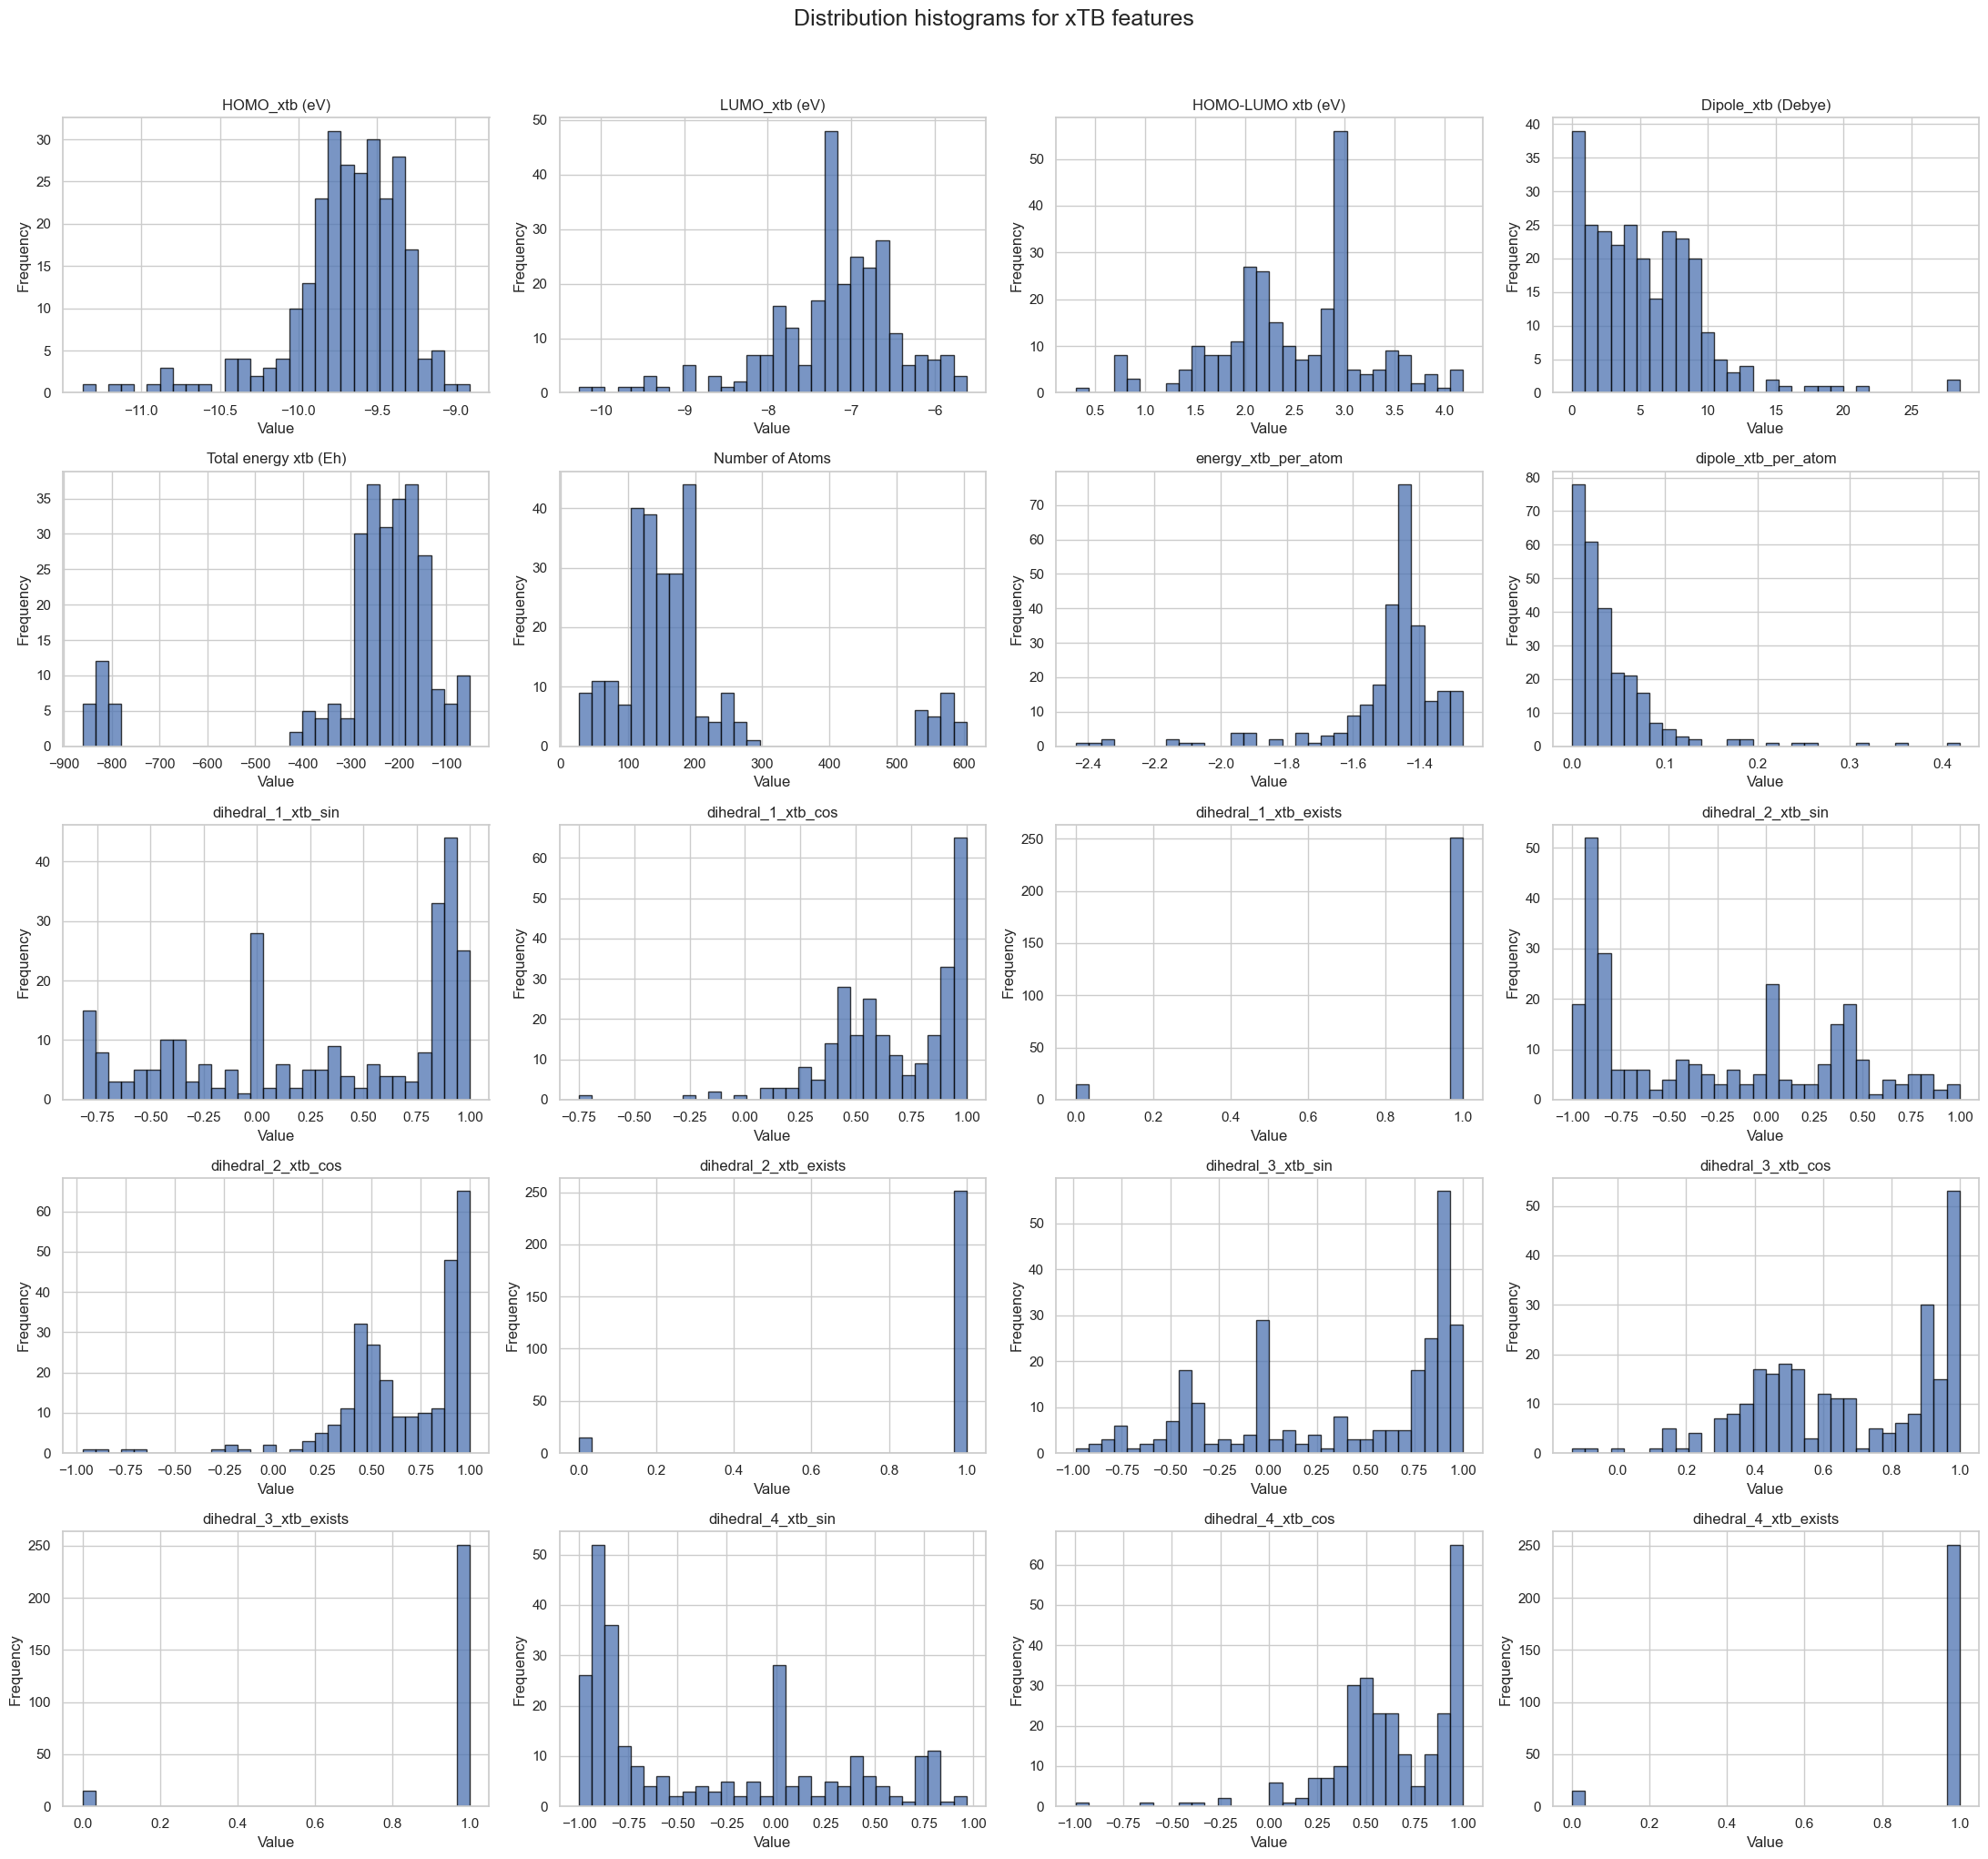

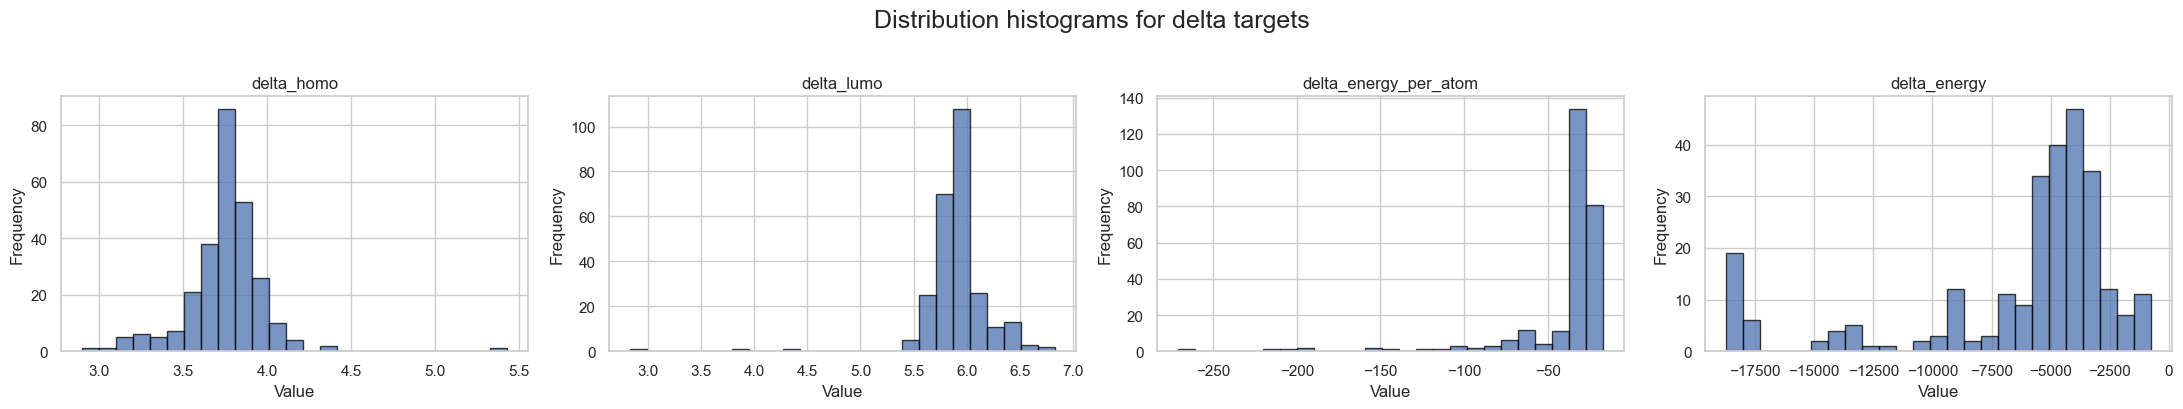

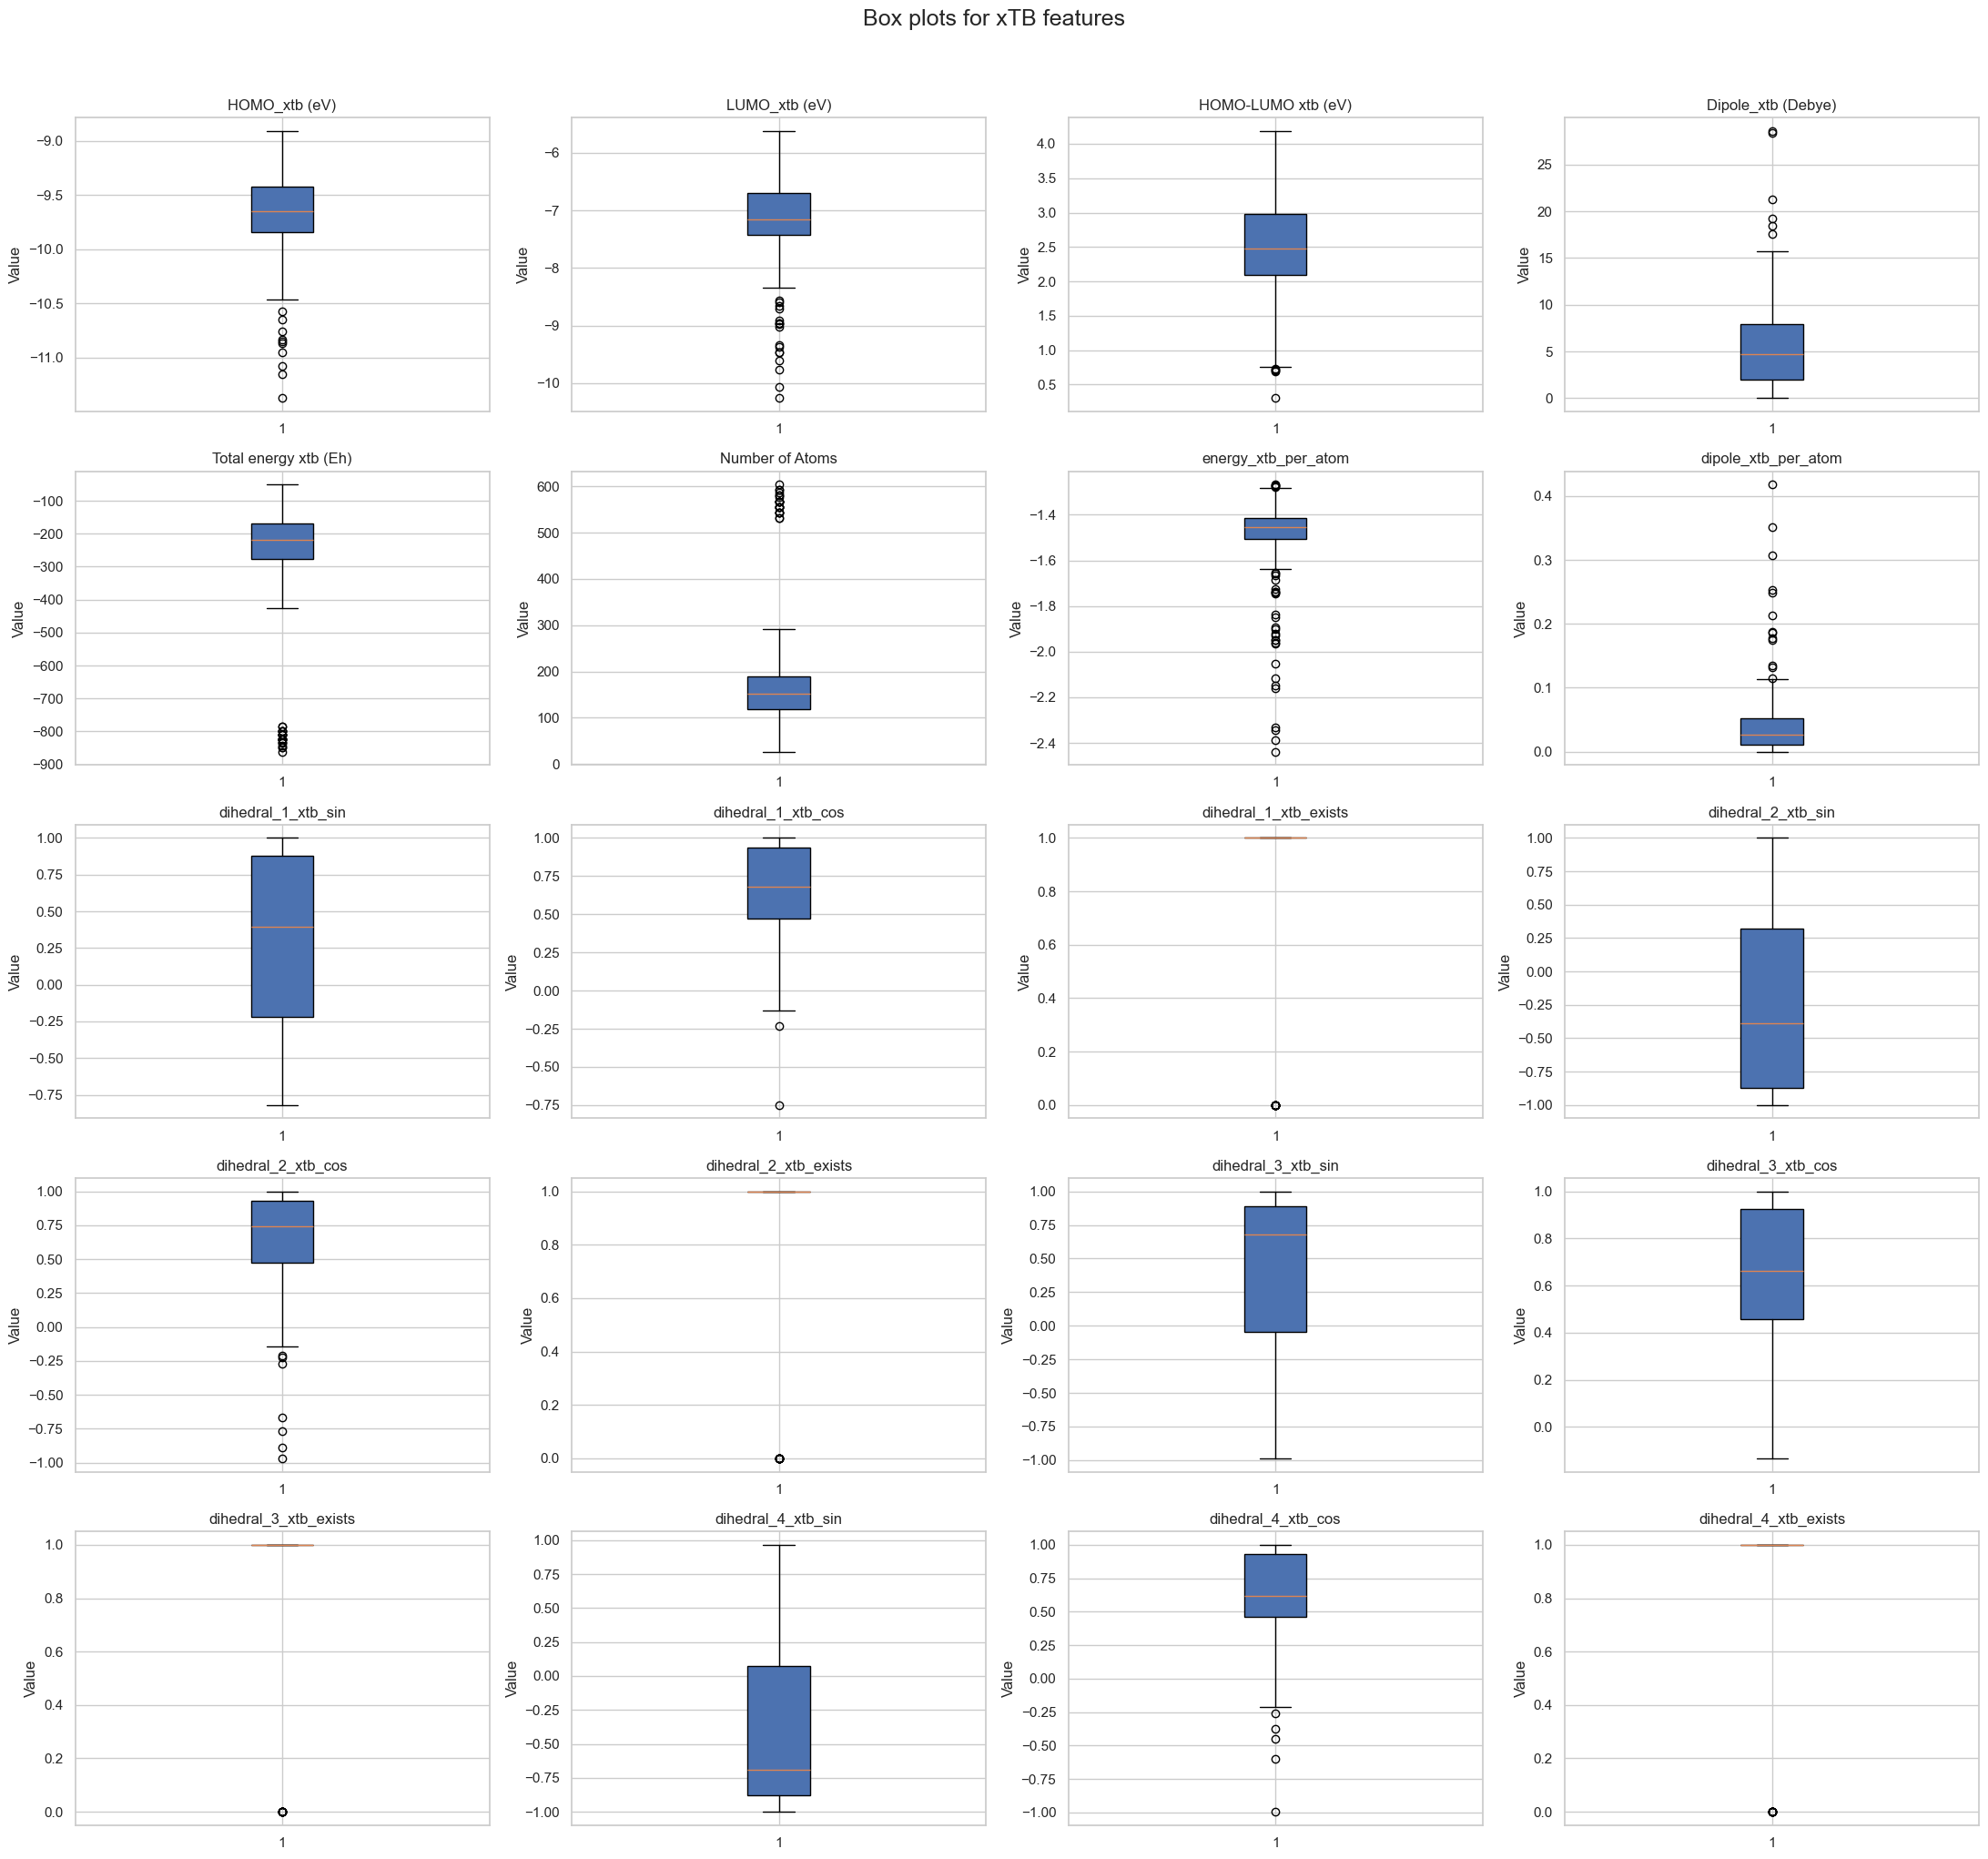

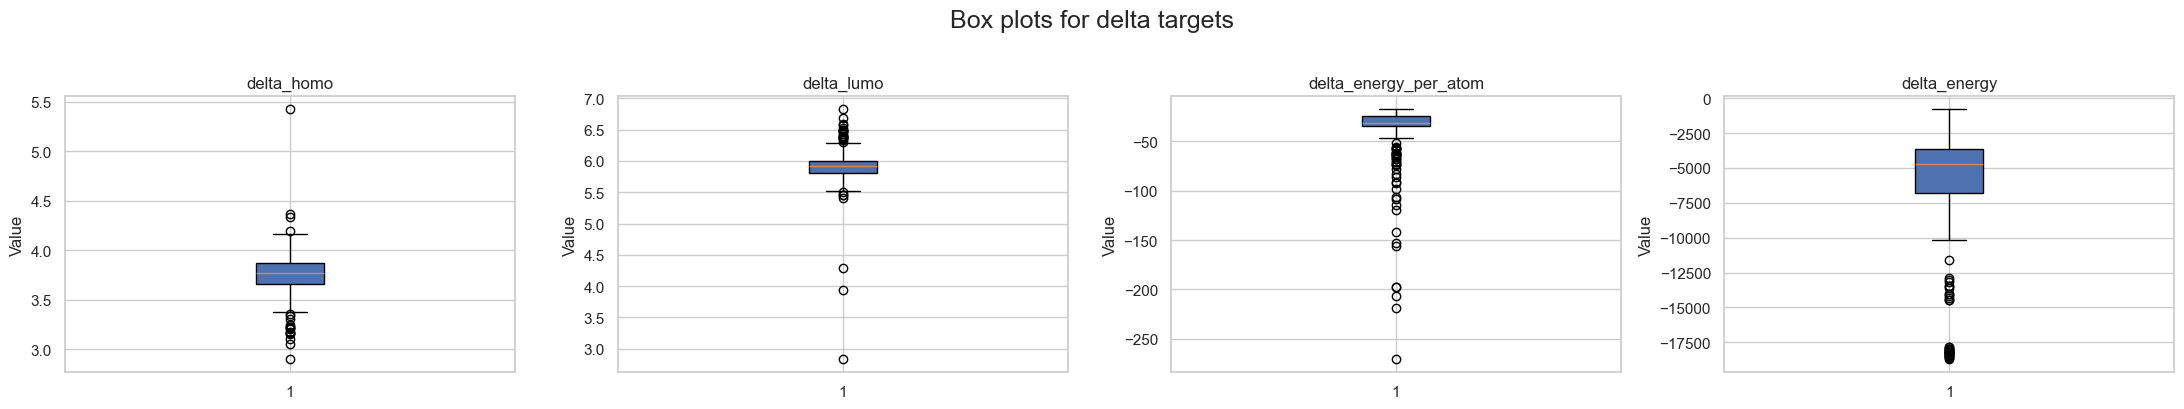

In [11]:

def plot_histograms(features, title, bins=30):
    n_cols = 4
    n_rows = int(np.ceil(len(features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, feature in enumerate(features):
        axes[i].hist(data[feature].dropna(), bins=bins, edgecolor="black", alpha=0.75)
        axes[i].set_title(feature)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")

    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_boxplots(features, title):
    n_cols = 4
    n_rows = int(np.ceil(len(features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, feature in enumerate(features):
        axes[i].boxplot(data[feature].dropna(), vert=True, patch_artist=True)
        axes[i].set_title(feature)
        axes[i].set_ylabel("Value")

    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

plot_histograms(xtb_features_eda, "Distribution histograms for xTB features")
plot_histograms(targets_eda, "Distribution histograms for delta targets", bins=25)

plot_boxplots(xtb_features_eda, "Box plots for xTB features")
plot_boxplots(targets_eda, "Box plots for delta targets")


## 2.7 P-values for Pearson correlations

In [12]:

p_values = pd.DataFrame(index=xtb_features_eda, columns=targets_eda)

for xtb in xtb_features_eda:
    for target in targets_eda:
        _, p_value = pearsonr(data[xtb], data[target])
        p_values.loc[xtb, target] = p_value

p_values


,delta_homo,delta_lumo,delta_energy_per_atom,delta_energy
HOMO_xtb (eV),0.470198,0.0,0.0,0.032688
LUMO_xtb (eV),0.0,0.0,0.000004,0.055915
HOMO-LUMO xtb (eV),0.0,0.000827,0.87355,0.001838
Dipole_xtb (Debye),0.09507,0.128563,0.431915,0.000048
Total energy xtb (Eh),0.110757,0.000001,0.008896,0.0
Number of Atoms,0.062513,0.0,0.001277,0.0
energy_xtb_per_atom,0.000038,0.0,0.0,0.463275
dipole_xtb_per_atom,0.0,0.000121,0.00178,0.001495
dihedral_1_xtb_sin,0.017966,0.206644,0.554606,0.0
dihedral_1_xtb_cos,0.027718,0.886635,0.3388,0.0


# 3. Frozen 80/20 split and evaluation setup

## 3.1 Define feature and target sets

In [13]:
features_common = [
    "HOMO_xtb (eV)",
    "LUMO_xtb (eV)",
    "HOMO-LUMO xtb (eV)",
    "Dipole_xtb (Debye)",
    "Total energy xtb (Eh)",
    "Number of Atoms",
    "energy_xtb_per_atom",
    "dipole_xtb_per_atom",
    "abs_homo_xtb",
    "abs_lumo_xtb",
    "dihedral_1_xtb_sin",
    "dihedral_1_xtb_cos",
    "dihedral_1_xtb_exists",
    "dihedral_2_xtb_sin",
    "dihedral_2_xtb_cos",
    "dihedral_2_xtb_exists",
    "dihedral_3_xtb_sin",
    "dihedral_3_xtb_cos",
    "dihedral_3_xtb_exists",
    "dihedral_4_xtb_sin",
    "dihedral_4_xtb_cos",
    "dihedral_4_xtb_exists",
]

target_homo = "delta_homo"
target_lumo = "delta_lumo"

energy_target_candidates = [
    "delta_energy_per_atom",
    "delta_energy",
    "Final Energy (Eh)",
]
target_energy_default = "delta_energy_per_atom"

metadata_cols = [c for c in ["Folder", "File", "SMILES"] if c in data.columns]

dataset = data[
    metadata_cols + features_common + [target_homo, target_lumo] + energy_target_candidates
].dropna().copy()
dataset["source_row_index"] = dataset.index
dataset = dataset.reset_index(drop=True)
dataset["row_index"] = dataset.index

if {"Folder", "File"}.issubset(dataset.columns):
    dataset["sample_id"] = dataset["Folder"].astype(str) + "/" + dataset["File"].astype(str)
else:
    dataset["sample_id"] = dataset.index.astype(str)

if "Folder" in dataset.columns:
    dataset["group_id"] = dataset["Folder"].astype(str)
else:
    dataset["group_id"] = dataset["sample_id"].astype(str)

metadata_export_cols = [
    c for c in ["row_index", "sample_id", "group_id", "Folder", "File", "SMILES"] if c in dataset.columns
]

X = dataset[features_common].copy()
y_homo = dataset[target_homo].copy()
y_lumo = dataset[target_lumo].copy()
y_energy = dataset[target_energy_default].copy()
groups = dataset["group_id"].copy()

print("X shape:", X.shape)
print("y_homo shape:", y_homo.shape)
print("y_lumo shape:", y_lumo.shape)
print("y_energy shape:", y_energy.shape)
print("Available energy targets:", energy_target_candidates)
print("Number of structural groups:", dataset["group_id"].nunique())

display(dataset[metadata_export_cols].head())


X shape: (266, 22)
y_homo shape: (266,)
y_lumo shape: (266,)
y_energy shape: (266,)
Available energy targets: ['delta_energy_per_atom', 'delta_energy', 'Final Energy (Eh)']
Number of structural groups: 22


,row_index,sample_id,group_id,Folder,File,SMILES
0,0,Group 1/1.log,Group 1,Group 1,1.log,OC1=C(CC2=C(C(CC3=C(O)C(CC4=CC(C(C)(C)C)=CC(CC...
1,1,Group 1/2.log,Group 1,Group 1,2.log,OC1=C(CC2=C(C(CC3=C(O)C(CC4=CC(Br)=CC(CC1=C5)=...
2,2,Group 1/3.log,Group 1,Group 1,3.log,OC1=C(CC2=CC(C(C)(C)C)=CC3=C2O)C=C(C(C)(C)C)C=...
3,3,Group 1/4.log,Group 1,Group 1,4.log,OC1=C(SC2=C(C(SC3=C(O)C(SC4=CC(C(C)(C)C)=CC(SC...
4,4,Group 1/5.log,Group 1,Group 1,5.log,OC1=C(SC2=C(C(SC3=C(O)C(S4)=CC=C3)=CC=C2)O)C=C...


## 3.2 Freeze current 80/20 split

In [14]:
HOLDOUT_SPLIT_TYPE = "frozen_group_holdout"

split_path = os.path.join(OUTPUT_DIR, "frozen_group_holdout.json")
split_artifacts_path = os.path.join(OUTPUT_DIR, "frozen_group_split_artifacts.csv")
split_group_summary_path = os.path.join(OUTPUT_DIR, "frozen_group_split_group_summary.csv")

stable_group_column = "Folder" if "Folder" in dataset.columns else "group_id"
groups = dataset[stable_group_column].astype(str)

recreate_split = False
split_info = None

if os.path.exists(split_path):
    with open(split_path, "r", encoding="utf-8") as f:
        split_info = json.load(f)

    print("Loaded frozen GROUP split from:", split_path)

    saved_train_groups = split_info.get("train_groups")
    saved_test_groups = split_info.get("test_groups")

    if saved_train_groups is None or saved_test_groups is None:
        recreate_split = True
    else:
        saved_train_groups = sorted([str(x) for x in saved_train_groups])
        saved_test_groups = sorted([str(x) for x in saved_test_groups])

        loaded_overlap = sorted(set(saved_train_groups) & set(saved_test_groups))
        if len(loaded_overlap) > 0:
            recreate_split = True
        else:
            train_indices = dataset.index[groups.isin(saved_train_groups)].tolist()
            test_indices = dataset.index[groups.isin(saved_test_groups)].tolist()

            current_groups = set(groups.unique())
            missing_saved_groups = sorted((set(saved_train_groups) | set(saved_test_groups)) - current_groups)

            if len(missing_saved_groups) > 0:
                recreate_split = True
else:
    recreate_split = True

if recreate_split:
    gss = GroupShuffleSplit(
        n_splits=1,
        test_size=0.2,
        random_state=RANDOM_STATE
    )

    train_pos, test_pos = next(gss.split(X, groups=groups))

    train_indices = X.index[train_pos].tolist()
    test_indices = X.index[test_pos].tolist()

    train_groups = sorted(dataset.loc[train_indices, stable_group_column].astype(str).unique().tolist())
    test_groups = sorted(dataset.loc[test_indices, stable_group_column].astype(str).unique().tolist())

    split_info = {
        "split_type": HOLDOUT_SPLIT_TYPE,
        "group_column": stable_group_column,
        "random_state": RANDOM_STATE,
        "test_size": 0.2,
        "train_groups": train_groups,
        "test_groups": test_groups,
        "n_train_groups": len(train_groups),
        "n_test_groups": len(test_groups),
        "group_overlap_count": 0,
        "train_indices": sorted(train_indices),
        "test_indices": sorted(test_indices),
        "train_source_row_indices": dataset.loc[train_indices, "source_row_index"].tolist(),
        "test_source_row_indices": dataset.loc[test_indices, "source_row_index"].tolist(),
    }

    with open(split_path, "w", encoding="utf-8") as f:
        json.dump(split_info, f, ensure_ascii=False, indent=4)

    print("Created and saved frozen GROUP split:", split_path)

train_groups = set(dataset.loc[train_indices, stable_group_column].astype(str))
test_groups = set(dataset.loc[test_indices, stable_group_column].astype(str))
group_overlap = sorted(train_groups & test_groups)

if len(group_overlap) > 0:
    raise RuntimeError(f"Group leakage detected in frozen hold-out split: {group_overlap}")

X_train = X.loc[train_indices].copy()
X_test = X.loc[test_indices].copy()

y_homo_train = y_homo.loc[train_indices].copy()
y_homo_test = y_homo.loc[test_indices].copy()

y_lumo_train = y_lumo.loc[train_indices].copy()
y_lumo_test = y_lumo.loc[test_indices].copy()

y_energy_train = y_energy.loc[train_indices].copy()
y_energy_test = y_energy.loc[test_indices].copy()

holdout_split_artifacts_df = dataset.loc[
    train_indices + test_indices,
    metadata_export_cols
].copy()

holdout_split_artifacts_df["subset"] = np.where(
    holdout_split_artifacts_df.index.isin(train_indices),
    "train",
    "test"
)

holdout_split_artifacts_df = holdout_split_artifacts_df[
    ["subset"] + metadata_export_cols
].sort_values(["subset", "group_id", "sample_id"]).reset_index(drop=True)

holdout_group_summary_df = pd.DataFrame({
    "subset": ["train", "test"],
    "n_samples": [len(train_indices), len(test_indices)],
    "n_groups": [len(train_groups), len(test_groups)],
})

holdout_split_artifacts_df.to_csv(split_artifacts_path, index=False)
holdout_group_summary_df.to_csv(split_group_summary_path, index=False)

print("Saved:", split_artifacts_path)
print("Saved:", split_group_summary_path)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train/Test ratio:", f"{len(X_train)}/{len(X_test)}")
print("Train groups:", len(train_groups))
print("Test groups:", len(test_groups))
print("Test group names:", sorted(test_groups))

Created and saved frozen GROUP split: ./output_final\frozen_group_holdout.json
Saved: ./output_final\frozen_group_split_artifacts.csv
Saved: ./output_final\frozen_group_split_group_summary.csv
Train shape: (223, 22)
Test shape: (43, 22)
Train/Test ratio: 223/43
Train groups: 17
Test groups: 5
Test group names: ['Group 1', 'Group 10', 'Group 17', 'Group 21', 'Group 3']


## 3.3 Robust weighting for energy target

In [15]:
def mad(arr):
    arr = np.asarray(arr, dtype=float)
    med = np.median(arr)
    return np.median(np.abs(arr - med))


def robust_sample_weights(y, c=2.5, min_weight=0.2):
    y = np.asarray(y, dtype=float)
    med = np.median(y)
    y_mad = mad(y)

    if y_mad < 1e-12:
        return np.ones_like(y, dtype=float)

    robust_z = 0.6745 * (y - med) / y_mad
    abs_z = np.abs(robust_z)

    weights = np.ones_like(abs_z, dtype=float)
    mask = abs_z > c
    weights[mask] = c / abs_z[mask]
    weights = np.clip(weights, min_weight, 1.0)

    return weights


def soft_sample_weights(y, c=3.5, min_weight=0.5):
    y = np.asarray(y, dtype=float)
    med = np.median(y)
    y_mad = mad(y)

    if y_mad < 1e-12:
        return np.ones_like(y, dtype=float)

    robust_z = 0.6745 * (y - med) / y_mad
    abs_z = np.abs(robust_z)

    weights = np.ones_like(abs_z, dtype=float)
    mask = abs_z > c
    weights[mask] = c / abs_z[mask]
    weights = np.clip(weights, min_weight, 1.0)

    return weights


def no_sample_weights(y):
    y = np.asarray(y, dtype=float)
    return np.ones_like(y, dtype=float)


weighting_schemes = {
    "robust": lambda y: robust_sample_weights(y, c=2.5, min_weight=0.2),
    "soft": lambda y: soft_sample_weights(y, c=3.5, min_weight=0.5),
    "none": lambda y: no_sample_weights(y),
}

energy_sample_weights_train = pd.DataFrame({
    "robust": weighting_schemes["robust"](y_energy_train),
    "soft": weighting_schemes["soft"](y_energy_train),
    "none": weighting_schemes["none"](y_energy_train),
}, index=y_energy_train.index)

print("Energy sample weights summary:")
display(energy_sample_weights_train.describe())

Energy sample weights summary:


,robust,soft,none
count,223.000000,223.000000,223.0
mean,0.915392,0.945061,1.0
std,0.219296,0.146841,0.0
min,0.200000,0.500000,1.0
25%,1.000000,1.000000,1.0
50%,1.000000,1.000000,1.0
75%,1.000000,1.000000,1.0
max,1.000000,1.000000,1.0


## 3.4 Weighting schemes for energy ablation

In [16]:
split_summary_df = pd.DataFrame({
    "subset": ["train", "test"],
    "n_samples": [len(X_train), len(X_test)],
    "n_groups": [
        dataset.loc[X_train.index, "group_id"].nunique(),
        dataset.loc[X_test.index, "group_id"].nunique(),
    ],
})

display(split_summary_df)


,subset,n_samples,n_groups
0,train,223,17
1,test,43,5


## 3.5 Helper variables for hold-out baseline

In [17]:
homo_xtb_test = X_test["HOMO_xtb (eV)"].values
lumo_xtb_test = X_test["LUMO_xtb (eV)"].values
energy_xtb_test = X_test["Total energy xtb (Eh)"].values

homo_true_test = data.loc[X_test.index, "HOMO_orca (eV)"].values
lumo_true_test = data.loc[X_test.index, "LUMO_orca (eV)"].values
energy_true_test = data.loc[X_test.index, "Final Energy (Eh)"].values

display(pd.DataFrame({
    "target": ["HOMO", "LUMO", "Final Energy"],
    "baseline_source": ["HOMO_xtb (eV)", "LUMO_xtb (eV)", "Total energy xtb (Eh)"],
    "n_test_samples": [len(X_test), len(X_test), len(X_test)],
}))

,target,baseline_source,n_test_samples
0,HOMO,HOMO_xtb (eV),43
1,LUMO,LUMO_xtb (eV),43
2,Final Energy,Total energy xtb (Eh),43


## 3.6 Helper metrics

In [18]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    abs_err = np.abs(y_pred - y_true)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MedAE": np.median(abs_err),
        "Q90_AE": np.quantile(abs_err, 0.90),
        "Q95_AE": np.quantile(abs_err, 0.95),
        "Max_AE": np.max(abs_err),
        "n_samples": len(y_true),
    }


def build_metrics_row(evaluation_type, split_type, model, target, unit, y_true, y_pred):
    row = {
        "evaluation_type": evaluation_type,
        "split_type": split_type,
        "model": model,
        "target": target,
        "unit": unit,
    }
    row.update(regression_metrics(y_true, y_pred))
    return row

## 3.7 Baseline hold-out metrics

In [19]:
baseline_holdout_rows = [
    build_metrics_row(
        evaluation_type="holdout_test",
        split_type=HOLDOUT_SPLIT_TYPE,
        model="xTB baseline",
        target="HOMO",
        unit="eV",
        y_true=homo_true_test,
        y_pred=homo_xtb_test,
    ),
    build_metrics_row(
        evaluation_type="holdout_test",
        split_type=HOLDOUT_SPLIT_TYPE,
        model="xTB baseline",
        target="LUMO",
        unit="eV",
        y_true=lumo_true_test,
        y_pred=lumo_xtb_test,
    ),
    build_metrics_row(
        evaluation_type="holdout_test",
        split_type=HOLDOUT_SPLIT_TYPE,
        model="xTB baseline",
        target="Final Energy",
        unit="Eh",
        y_true=energy_true_test,
        y_pred=energy_xtb_test,
    ),
]

baseline_holdout_metrics_df = pd.DataFrame(baseline_holdout_rows)
baseline_holdout_metrics_df

,evaluation_type,split_type,model,target,unit,MAE,RMSE,R2,MedAE,Q90_AE,Q95_AE,Max_AE,n_samples
0,holdout_test,frozen_group_holdout,xTB baseline,HOMO,eV,3.662334,3.672731,-34.544058,3.729269,3.954178,3.985563,4.336491,43
1,holdout_test,frozen_group_holdout,xTB baseline,LUMO,eV,6.001454,6.007786,-108.745052,5.906589,6.441960,6.565935,6.831011,43
2,holdout_test,frozen_group_holdout,xTB baseline,Final Energy,Eh,5554.592625,6659.545933,-2.221717,4691.222326,12625.511525,13133.239372,14444.651477,43


## 3.8 Repeated nested cross-validation on the training set

In [20]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_OUTER_SPLITS = 5
N_OUTER_REPEATS = 3
N_INNER_SPLITS = 4

MODEL_NAMES = [
    "LinearRegression",
    "Ridge",
    "ElasticNet",
    "KernelRidge",
    "RandomForest",
    "XGBoost",
]

MODEL_TRIALS = {
    "LinearRegression": 1,
    "Ridge": 40,
    "ElasticNet": 40,
    "KernelRidge": 40,
    "RandomForest": 60,
    "XGBoost": 80,
}

SCALED_MODELS = {"LinearRegression", "Ridge", "ElasticNet", "KernelRidge"}
WEIGHTED_MODELS = {"RandomForest", "XGBoost"}

ENERGY_TARGET_MODES = [
    "delta_energy_per_atom",
    "delta_energy",
    "final_energy_direct",
]

ENERGY_WEIGHT_SCHEMES = ["none", "soft", "robust"]

In [21]:
def restore_energy_from_target(X_part, y_pred_target, target_mode):
    energy_xtb = X_part["Total energy xtb (Eh)"].values
    n_atoms = X_part["Number of Atoms"].values
    y_pred_target = np.asarray(y_pred_target, dtype=float)

    if target_mode == "delta_energy_per_atom":
        return energy_xtb + y_pred_target * n_atoms
    elif target_mode == "delta_energy":
        return energy_xtb + y_pred_target
    elif target_mode == "final_energy_direct":
        return y_pred_target


def get_energy_target_for_indices(indices, target_mode):
    if target_mode == "delta_energy_per_atom":
        return dataset.loc[indices, "delta_energy_per_atom"].copy()
    elif target_mode == "delta_energy":
        return dataset.loc[indices, "delta_energy"].copy()
    elif target_mode == "final_energy_direct":
        return dataset.loc[indices, "Final Energy (Eh)"].copy()

def default_inner_mae(X_valid, y_valid, y_pred):
    return mean_absolute_error(
        np.asarray(y_valid, dtype=float),
        np.asarray(y_pred, dtype=float)
    )

def energy_inner_mae_from_restored(target_mode):
    def _score(X_valid, y_valid, y_pred):
        y_true_abs = dataset.loc[X_valid.index, "Final Energy (Eh)"].values
        y_pred_abs = restore_energy_from_target(
            X_valid,
            y_pred,
            target_mode=target_mode
        )
        return mean_absolute_error(y_true_abs, y_pred_abs)

    return _score

def make_group_folds(group_series, n_splits, random_state):
    group_series = pd.Series(group_series).reset_index(drop=True)

    unique_groups = group_series.drop_duplicates().tolist()
    if len(unique_groups) < n_splits:
        raise ValueError(
            f"Not enough unique groups for {n_splits}-fold CV: "
            f"found only {len(unique_groups)} groups."
        )

    group_sizes = group_series.value_counts().to_dict()
    rng = np.random.RandomState(random_state)

    shuffled_groups = unique_groups.copy()
    rng.shuffle(shuffled_groups)

    fold_groups = [set() for _ in range(n_splits)]
    fold_sizes = [0] * n_splits

    for group_name in sorted(shuffled_groups, key=lambda x: group_sizes[x], reverse=True):
        target_fold = int(np.argmin(fold_sizes))
        fold_groups[target_fold].add(group_name)
        fold_sizes[target_fold] += group_sizes[group_name]

    splits = []
    for fold_id in range(1, n_splits + 1):
        valid_mask = group_series.isin(fold_groups[fold_id - 1]).to_numpy()
        valid_idx = np.where(valid_mask)[0]
        train_idx = np.where(~valid_mask)[0]
        splits.append((fold_id, train_idx, valid_idx))

    return splits


def make_repeated_group_folds(group_series, n_splits, n_repeats, random_state):
    all_splits = []
    for repeat_id in range(1, n_repeats + 1):
        repeat_seed = random_state + repeat_id * 1000
        repeat_splits = make_group_folds(
            group_series=group_series,
            n_splits=n_splits,
            random_state=repeat_seed
        )
        for fold_id, train_idx, valid_idx in repeat_splits:
            all_splits.append((repeat_id, fold_id, train_idx, valid_idx))
    return all_splits


def assert_no_group_leakage(group_series, train_idx, valid_idx):
    group_series = pd.Series(group_series).reset_index(drop=True).astype(str)
    train_groups = set(group_series.iloc[train_idx])
    valid_groups = set(group_series.iloc[valid_idx])
    overlap = sorted(train_groups & valid_groups)
    if len(overlap) > 0:
        raise RuntimeError(f"Group leakage detected: {overlap}")


def build_split_artifact(
    frame,
    indices,
    split_level,
    split_role,
    repeat_id=None,
    split_id=None,
    outer_fold=None,
    inner_fold=None,
    target_name=None
):
    keep_cols = [c for c in metadata_export_cols if c in frame.columns]
    out = frame.iloc[indices][keep_cols].copy()
    out["split_level"] = split_level
    out["split_role"] = split_role
    out["repeat_id"] = repeat_id
    out["split_id"] = split_id
    out["outer_fold"] = outer_fold
    out["inner_fold"] = inner_fold
    out["target_name"] = target_name

    ordered_cols = [
        "split_level",
        "split_role",
        "repeat_id",
        "split_id",
        "outer_fold",
        "inner_fold",
        "target_name",
    ] + keep_cols

    return out[ordered_cols]


def build_split_summary(
    frame,
    train_idx,
    valid_idx,
    split_level,
    repeat_id=None,
    split_id=None,
    outer_fold=None,
    inner_fold=None,
    target_name=None
):
    group_series = frame["group_id"].astype(str).reset_index(drop=True)
    train_groups = set(group_series.iloc[train_idx])
    valid_groups = set(group_series.iloc[valid_idx])
    overlap = sorted(train_groups & valid_groups)

    return {
        "split_level": split_level,
        "repeat_id": repeat_id,
        "split_id": split_id,
        "outer_fold": outer_fold,
        "inner_fold": inner_fold,
        "target_name": target_name,
        "n_train_samples": len(train_idx),
        "n_valid_samples": len(valid_idx),
        "n_train_groups": len(train_groups),
        "n_valid_groups": len(valid_groups),
        "n_overlap_groups": len(overlap),
        "overlap_groups": "|".join(overlap),
    }


def suggest_model_params(trial, model_name):
    if model_name == "LinearRegression":
        return {}

    if model_name == "Ridge":
        return {
            "alpha": trial.suggest_float("alpha", 1e-4, 1e3, log=True)
        }

    if model_name == "ElasticNet":
        return {
            "alpha": trial.suggest_float("alpha", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.05, 0.95),
        }

    if model_name == "KernelRidge":
        return {
            "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),
            "gamma": trial.suggest_float("gamma", 1e-3, 10.0, log=True),
        }

    if model_name == "RandomForest":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
            "max_depth": trial.suggest_int("max_depth", 3, 18),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 4),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        }

    if model_name == "XGBoost":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 300, 1400),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 5e-2, log=True),
            "subsample": trial.suggest_float("subsample", 0.7, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-5, 10.0, log=True),
            "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        }

    raise ValueError(f"Unknown model_name: {model_name}")


def build_model(model_name, params, seed):
    if model_name == "LinearRegression":
        return LinearRegression()

    if model_name == "Ridge":
        return Ridge(max_iter=100000, **params)

    if model_name == "ElasticNet":
        return ElasticNet(max_iter=100000, **params)

    if model_name == "KernelRidge":
        return KernelRidge(kernel="rbf", **params)

    if model_name == "RandomForest":
        return RandomForestRegressor(
            random_state=seed,
            n_jobs=-1,
            **params
        )

    if model_name == "XGBoost":
        return XGBRegressor(
            objective="reg:squarederror",
            eval_metric="mae",
            random_state=seed,
            n_jobs=-1,
            **params
        )

    raise ValueError(f"Unknown model_name: {model_name}")


def fit_and_predict_single(
    X_fit,
    y_fit,
    X_pred,
    model_name,
    params,
    seed,
    weight_scheme_name=None
):
    if model_name in SCALED_MODELS:
        scaler_X = StandardScaler()
        X_fit_scaled = scaler_X.fit_transform(X_fit)
        X_pred_scaled = scaler_X.transform(X_pred)

        scaler_y = StandardScaler()
        y_fit_scaled = scaler_y.fit_transform(y_fit.to_frame()).ravel()

        model = build_model(model_name, params, seed)
        model.fit(X_fit_scaled, y_fit_scaled)

        y_pred_scaled = np.asarray(model.predict(X_pred_scaled)).reshape(-1, 1)
        y_pred = scaler_y.inverse_transform(y_pred_scaled).ravel()

        return model, scaler_X, scaler_y, y_pred

    model = build_model(model_name, params, seed)
    fit_kwargs = {}

    if weight_scheme_name is not None and model_name in WEIGHTED_MODELS:
        fit_kwargs["sample_weight"] = weighting_schemes[weight_scheme_name](y_fit)

    model.fit(X_fit, y_fit, **fit_kwargs)
    y_pred = np.asarray(model.predict(X_pred), dtype=float).ravel()

    return model, None, None, y_pred

def fit_predict_model_nested(
    X_outer_train,
    y_outer_train,
    X_outer_valid,
    model_name,
    n_trials,
    seed,
    inner_splits,
    weight_scheme_name=None,
    inner_score_fn=None
):
    scorer_fn = default_inner_mae if inner_score_fn is None else inner_score_fn

    def objective(trial):
        params = suggest_model_params(trial, model_name)
        fold_scores = []

        for _, inner_train_idx, inner_valid_idx in inner_splits:
            X_inner_train = X_outer_train.iloc[inner_train_idx]
            X_inner_valid = X_outer_train.iloc[inner_valid_idx]

            y_inner_train = y_outer_train.iloc[inner_train_idx]
            y_inner_valid = y_outer_train.iloc[inner_valid_idx]

            _, _, _, y_inner_pred = fit_and_predict_single(
                X_fit=X_inner_train,
                y_fit=y_inner_train,
                X_pred=X_inner_valid,
                model_name=model_name,
                params=params,
                seed=seed,
                weight_scheme_name=weight_scheme_name
            )

            fold_scores.append(
                scorer_fn(X_inner_valid, y_inner_valid, y_inner_pred)
            )

        return float(np.mean(fold_scores))

    study = optuna.create_study(
        direction="minimize",
        sampler=TPESampler(seed=seed)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = study.best_params.copy()

    model, scaler_X, scaler_y, y_outer_pred = fit_and_predict_single(
        X_fit=X_outer_train,
        y_fit=y_outer_train,
        X_pred=X_outer_valid,
        model_name=model_name,
        params=best_params,
        seed=seed,
        weight_scheme_name=weight_scheme_name
    )

    return model, scaler_X, scaler_y, y_outer_pred, best_params, study.best_value

In [22]:
nested_rows = []

outer_split_artifacts_rows = []
outer_split_summary_rows = []
inner_split_artifacts_rows = []
inner_split_summary_rows = []

train_metadata_df = dataset.loc[X_train.index, metadata_export_cols].copy().reset_index(drop=True)
train_groups_local = train_metadata_df["group_id"].copy()

outer_cv_splits = make_repeated_group_folds(
    group_series=train_groups_local,
    n_splits=N_OUTER_SPLITS,
    n_repeats=N_OUTER_REPEATS,
    random_state=RANDOM_STATE
)

for outer_fold, (repeat_id, split_id, outer_train_idx, outer_valid_idx) in enumerate(outer_cv_splits, start=1):
    fold_seed = RANDOM_STATE + outer_fold

    print(f"Outer fold {outer_fold} / {N_OUTER_SPLITS * N_OUTER_REPEATS} | repeat={repeat_id}, split={split_id}")

    assert_no_group_leakage(train_groups_local, outer_train_idx, outer_valid_idx)

    outer_split_artifacts_rows.append(
        build_split_artifact(
            frame=train_metadata_df,
            indices=outer_train_idx,
            split_level="outer_cv",
            split_role="train",
            repeat_id=repeat_id,
            split_id=split_id,
            outer_fold=outer_fold
        )
    )

    outer_split_artifacts_rows.append(
        build_split_artifact(
            frame=train_metadata_df,
            indices=outer_valid_idx,
            split_level="outer_cv",
            split_role="valid",
            repeat_id=repeat_id,
            split_id=split_id,
            outer_fold=outer_fold
        )
    )

    outer_split_summary_rows.append(
        build_split_summary(
            frame=train_metadata_df,
            train_idx=outer_train_idx,
            valid_idx=outer_valid_idx,
            split_level="outer_cv",
            repeat_id=repeat_id,
            split_id=split_id,
            outer_fold=outer_fold
        )
    )

    X_outer_train = X_train.iloc[outer_train_idx].copy()
    X_outer_valid = X_train.iloc[outer_valid_idx].copy()

    y_homo_outer_train = y_homo_train.iloc[outer_train_idx].copy()
    y_homo_outer_valid = y_homo_train.iloc[outer_valid_idx].copy()

    y_lumo_outer_train = y_lumo_train.iloc[outer_train_idx].copy()
    y_lumo_outer_valid = y_lumo_train.iloc[outer_valid_idx].copy()

    outer_train_metadata_df = train_metadata_df.iloc[outer_train_idx].reset_index(drop=True)
    inner_splits = make_group_folds(
        group_series=outer_train_metadata_df["group_id"],
        n_splits=N_INNER_SPLITS,
        random_state=fold_seed + 500
    )

    for inner_fold_id, inner_train_idx, inner_valid_idx in inner_splits:
        assert_no_group_leakage(outer_train_metadata_df["group_id"], inner_train_idx, inner_valid_idx)

        inner_split_artifacts_rows.append(
            build_split_artifact(
                frame=outer_train_metadata_df,
                indices=inner_train_idx,
                split_level="inner_cv",
                split_role="train",
                repeat_id=repeat_id,
                split_id=split_id,
                outer_fold=outer_fold,
                inner_fold=inner_fold_id,
                target_name="shared_nested_tuning"
            )
        )

        inner_split_artifacts_rows.append(
            build_split_artifact(
                frame=outer_train_metadata_df,
                indices=inner_valid_idx,
                split_level="inner_cv",
                split_role="valid",
                repeat_id=repeat_id,
                split_id=split_id,
                outer_fold=outer_fold,
                inner_fold=inner_fold_id,
                target_name="shared_nested_tuning"
            )
        )

        inner_split_summary_rows.append(
            build_split_summary(
                frame=outer_train_metadata_df,
                train_idx=inner_train_idx,
                valid_idx=inner_valid_idx,
                split_level="inner_cv",
                repeat_id=repeat_id,
                split_id=split_id,
                outer_fold=outer_fold,
                inner_fold=inner_fold_id,
                target_name="shared_nested_tuning"
            )
        )

    for target_name, delta_target_name, xtb_col, true_col, y_outer_train_target, y_outer_valid_target in [
        ("HOMO", "delta_homo", "HOMO_xtb (eV)", "HOMO_orca (eV)", y_homo_outer_train, y_homo_outer_valid),
        ("LUMO", "delta_lumo", "LUMO_xtb (eV)", "LUMO_orca (eV)", y_lumo_outer_train, y_lumo_outer_valid),
    ]:
        for model_idx, model_name in enumerate(MODEL_NAMES):
            _, _, _, y_delta_pred_cv, best_params_cv, best_inner_cv = fit_predict_model_nested(
                X_outer_train=X_outer_train,
                y_outer_train=y_outer_train_target,
                X_outer_valid=X_outer_valid,
                model_name=model_name,
                n_trials=MODEL_TRIALS[model_name],
                seed=fold_seed + (model_idx + 1) * 1000,
                inner_splits=inner_splits,
                weight_scheme_name=None
            )

            y_pred_abs_cv = X_outer_valid[xtb_col].values + y_delta_pred_cv
            y_true_abs_cv = data.loc[X_outer_valid.index, true_col].values

            abs_metrics = regression_metrics(y_true_abs_cv, y_pred_abs_cv)
            delta_metrics = regression_metrics(y_outer_valid_target.values, y_delta_pred_cv)

            nested_rows.append({
                "outer_fold": outer_fold,
                "repeat_id": repeat_id,
                "split_id": split_id,
                "model": model_name,
                "target": target_name,
                **abs_metrics,
                "best_params_json": json.dumps(best_params_cv),
                "best_inner_score": best_inner_cv,
            })

            nested_rows.append({
                "outer_fold": outer_fold,
                "repeat_id": repeat_id,
                "split_id": split_id,
                "model": model_name,
                "target": delta_target_name,
                **delta_metrics,
                "best_params_json": json.dumps(best_params_cv),
                "best_inner_score": best_inner_cv,
            })

    for energy_target_mode_idx, energy_target_mode in enumerate(ENERGY_TARGET_MODES, start=1):
        y_energy_outer_train = get_energy_target_for_indices(
            X_outer_train.index,
            energy_target_mode
        )
        y_energy_outer_valid = get_energy_target_for_indices(
            X_outer_valid.index,
            energy_target_mode
        )

        for model_idx, model_name in enumerate(MODEL_NAMES):
            weight_schemes_local = (
                ENERGY_WEIGHT_SCHEMES if model_name in WEIGHTED_MODELS else ["none"]
            )

            for weight_scheme_idx, energy_weight_scheme_name in enumerate(weight_schemes_local, start=1):
                fit_weight_scheme_name = (
                    energy_weight_scheme_name if model_name in WEIGHTED_MODELS else None
                )

                energy_seed = (
                    fold_seed
                    + 100000
                    + energy_target_mode_idx * 10000
                    + (model_idx + 1) * 1000
                    + weight_scheme_idx * 100
                )

                _, _, _, y_energy_pred_cv, best_params_energy_cv, best_inner_energy_cv = fit_predict_model_nested(
                    X_outer_train=X_outer_train,
                    y_outer_train=y_energy_outer_train,
                    X_outer_valid=X_outer_valid,
                    model_name=model_name,
                    n_trials=MODEL_TRIALS[model_name],
                    seed=energy_seed,
                    inner_splits=inner_splits,
                    weight_scheme_name=fit_weight_scheme_name,
                    inner_score_fn=energy_inner_mae_from_restored(energy_target_mode)
                )

                energy_pred_cv = restore_energy_from_target(
                    X_outer_valid,
                    y_energy_pred_cv,
                    target_mode=energy_target_mode
                )
                energy_true_cv = data.loc[X_outer_valid.index, "Final Energy (Eh)"].values

                energy_abs_metrics = regression_metrics(energy_true_cv, energy_pred_cv)
                energy_target_metrics = regression_metrics(y_energy_outer_valid.values, y_energy_pred_cv)

                nested_rows.append({
                    "outer_fold": outer_fold,
                    "repeat_id": repeat_id,
                    "split_id": split_id,
                    "model": model_name,
                    "target": "Final Energy",
                    "energy_target_mode": energy_target_mode,
                    "weight_scheme": energy_weight_scheme_name,
                    **energy_abs_metrics,
                    "best_params_json": json.dumps(best_params_energy_cv),
                    "best_inner_score": best_inner_energy_cv,
                })

                nested_rows.append({
                    "outer_fold": outer_fold,
                    "repeat_id": repeat_id,
                    "split_id": split_id,
                    "model": model_name,
                    "target": energy_target_mode,
                    "energy_target_mode": energy_target_mode,
                    "weight_scheme": energy_weight_scheme_name,
                    **energy_target_metrics,
                    "best_params_json": json.dumps(best_params_energy_cv),
                    "best_inner_score": best_inner_energy_cv,
                })

outer_split_artifacts_df = pd.concat(outer_split_artifacts_rows, ignore_index=True)
outer_split_summary_df = pd.DataFrame(outer_split_summary_rows)

inner_split_artifacts_df = pd.concat(inner_split_artifacts_rows, ignore_index=True)
inner_split_summary_df = pd.DataFrame(inner_split_summary_rows)

outer_split_artifacts_df.to_csv(
    os.path.join(OUTPUT_DIR, "outer_cv_split_artifacts.csv"),
    index=False
)
outer_split_summary_df.to_csv(
    os.path.join(OUTPUT_DIR, "outer_cv_split_summary.csv"),
    index=False
)
inner_split_artifacts_df.to_csv(
    os.path.join(OUTPUT_DIR, "inner_cv_split_artifacts.csv"),
    index=False
)
inner_split_summary_df.to_csv(
    os.path.join(OUTPUT_DIR, "inner_cv_split_summary.csv"),
    index=False
)

print("Saved:", os.path.join(OUTPUT_DIR, "outer_cv_split_artifacts.csv"))
print("Saved:", os.path.join(OUTPUT_DIR, "outer_cv_split_summary.csv"))
print("Saved:", os.path.join(OUTPUT_DIR, "inner_cv_split_artifacts.csv"))
print("Saved:", os.path.join(OUTPUT_DIR, "inner_cv_split_summary.csv"))


Outer fold 1 / 15 | repeat=1, split=1
Outer fold 2 / 15 | repeat=1, split=2
Outer fold 3 / 15 | repeat=1, split=3
Outer fold 4 / 15 | repeat=1, split=4
Outer fold 5 / 15 | repeat=1, split=5
Outer fold 6 / 15 | repeat=2, split=1
Outer fold 7 / 15 | repeat=2, split=2
Outer fold 8 / 15 | repeat=2, split=3
Outer fold 9 / 15 | repeat=2, split=4
Outer fold 10 / 15 | repeat=2, split=5
Outer fold 11 / 15 | repeat=3, split=1
Outer fold 12 / 15 | repeat=3, split=2
Outer fold 13 / 15 | repeat=3, split=3
Outer fold 14 / 15 | repeat=3, split=4
Outer fold 15 / 15 | repeat=3, split=5
Saved: ./output_final\outer_cv_split_artifacts.csv
Saved: ./output_final\outer_cv_split_summary.csv
Saved: ./output_final\inner_cv_split_artifacts.csv
Saved: ./output_final\inner_cv_split_summary.csv


In [23]:

nested_cv_fold_df = pd.DataFrame(nested_rows)

nested_cv_summary_main_df = (
    nested_cv_fold_df[
        nested_cv_fold_df["target"].isin(["HOMO", "LUMO", "delta_homo", "delta_lumo"])
    ]
    .groupby(["model", "target"])
    .agg(
        cv_mae_mean=("MAE", "mean"),
        cv_mae_std=("MAE", "std"),
        cv_rmse_mean=("RMSE", "mean"),
        cv_rmse_std=("RMSE", "std"),
        cv_r2_mean=("R2", "mean"),
        cv_r2_std=("R2", "std"),
        cv_medae_mean=("MedAE", "mean"),
        cv_q90ae_mean=("Q90_AE", "mean"),
        cv_q95ae_mean=("Q95_AE", "mean"),
        n_outer_folds=("outer_fold", "count")
    )
    .reset_index()
    .sort_values(["target", "cv_mae_mean", "cv_q95ae_mean"])
)

energy_targets_for_summary = ["Final Energy"] + ENERGY_TARGET_MODES

nested_cv_summary_energy_df = (
    nested_cv_fold_df[
        nested_cv_fold_df["target"].isin(energy_targets_for_summary)
    ]
    .groupby(["model", "target", "energy_target_mode", "weight_scheme"])
    .agg(
        cv_mae_mean=("MAE", "mean"),
        cv_mae_std=("MAE", "std"),
        cv_rmse_mean=("RMSE", "mean"),
        cv_rmse_std=("RMSE", "std"),
        cv_r2_mean=("R2", "mean"),
        cv_r2_std=("R2", "std"),
        cv_medae_mean=("MedAE", "mean"),
        cv_q90ae_mean=("Q90_AE", "mean"),
        cv_q95ae_mean=("Q95_AE", "mean"),
        n_outer_folds=("outer_fold", "count")
    )
    .reset_index()
    .sort_values(["target", "energy_target_mode", "weight_scheme", "cv_mae_mean", "cv_q95ae_mean"])
)

nested_cv_fold_path = os.path.join(OUTPUT_DIR, "nested_repeated_cv_fold_metrics.csv")
nested_cv_summary_main_path = os.path.join(OUTPUT_DIR, "nested_repeated_cv_summary_main.csv")
nested_cv_summary_energy_path = os.path.join(OUTPUT_DIR, "nested_repeated_cv_summary_energy.csv")
nested_cv_params_path = os.path.join(OUTPUT_DIR, "nested_repeated_cv_best_params.json")

nested_cv_fold_df.to_csv(nested_cv_fold_path, index=False)
nested_cv_summary_main_df.to_csv(nested_cv_summary_main_path, index=False)
nested_cv_summary_energy_df.to_csv(nested_cv_summary_energy_path, index=False)

with open(nested_cv_params_path, "w", encoding="utf-8") as f:
    json.dump(
        nested_cv_fold_df[
            [col for col in nested_cv_fold_df.columns if col in [
                "outer_fold", "repeat_id", "split_id", "model", "target",
                "energy_target_mode", "weight_scheme", "best_params_json", "best_inner_score"
            ]]
        ].to_dict(orient="records"),
        f,
        ensure_ascii=False,
        indent=4
    )

print("Saved:", nested_cv_fold_path)
print("Saved:", nested_cv_summary_main_path)
print("Saved:", nested_cv_summary_energy_path)
print("Saved:", nested_cv_params_path)

print("\nHOMO/LUMO summary")
display(nested_cv_summary_main_df)

print("\nENERGY summary")
display(nested_cv_summary_energy_df)


Saved: ./output_final\nested_repeated_cv_fold_metrics.csv
Saved: ./output_final\nested_repeated_cv_summary_main.csv
Saved: ./output_final\nested_repeated_cv_summary_energy.csv
Saved: ./output_final\nested_repeated_cv_best_params.json

HOMO/LUMO summary


,model,target,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,cv_medae_mean,cv_q90ae_mean,cv_q95ae_mean,n_outer_folds
4,KernelRidge,HOMO,0.134159,0.042677,0.205340,0.081738,0.510679,0.219141,0.082858,0.316021,0.391300,15
12,RandomForest,HOMO,0.139081,0.048436,0.211024,0.082587,0.402615,0.505067,0.086123,0.308167,0.404285,15
20,XGBoost,HOMO,0.143210,0.042362,0.213807,0.076025,0.409975,0.421303,0.091838,0.314864,0.410305,15
16,Ridge,HOMO,0.149087,0.060260,0.207070,0.085228,0.506431,0.228138,0.108963,0.309874,0.388151,15
0,ElasticNet,HOMO,0.151864,0.054131,0.211303,0.081723,0.484502,0.231757,0.111032,0.314500,0.400385,15
8,LinearRegression,HOMO,0.162649,0.088525,0.221164,0.105995,0.438654,0.283271,0.124698,0.318625,0.419507,15
17,Ridge,LUMO,0.170599,0.060346,0.284863,0.151346,0.802037,0.131245,0.118635,0.325690,0.403562,15
5,KernelRidge,LUMO,0.172947,0.073480,0.293495,0.166763,0.792864,0.139711,0.112810,0.343804,0.437969,15
13,RandomForest,LUMO,0.175754,0.079745,0.294897,0.170481,0.787616,0.149273,0.121975,0.323255,0.419019,15
1,ElasticNet,LUMO,0.178427,0.064304,0.293887,0.158655,0.790820,0.143610,0.121704,0.340595,0.423017,15



ENERGY summary


,model,target,energy_target_mode,weight_scheme,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,cv_medae_mean,cv_q90ae_mean,cv_q95ae_mean,n_outer_folds
18,RandomForest,Final Energy,delta_energy,none,2599.722280,2044.589328,3540.032268,2453.008367,-0.388428,0.491155,2680.382213,5497.788656,6444.538989,15
42,XGBoost,Final Energy,delta_energy,none,2816.971745,2100.222549,3900.752179,2422.834920,-0.917138,0.814288,2902.768393,6101.814117,6881.471595,15
12,LinearRegression,Final Energy,delta_energy,none,2916.260172,1392.249811,3661.194759,1530.847387,-1.247217,1.611807,2914.955525,5250.963686,6273.025584,15
36,Ridge,Final Energy,delta_energy,none,3113.396987,2064.978513,3902.187081,2488.988108,-1.034536,1.391175,3705.447370,5473.583074,6312.146163,15
0,ElasticNet,Final Energy,delta_energy,none,3259.596216,2241.892537,4128.605139,2712.964576,-1.197151,1.387642,3763.539930,5948.738551,6802.299336,15
6,KernelRidge,Final Energy,delta_energy,none,3356.224475,2486.816548,4413.947967,2893.086382,-1.870683,2.193442,4068.011258,6166.218845,7136.396246,15
19,RandomForest,Final Energy,delta_energy,robust,2874.636155,2402.159447,3879.105106,2865.198720,-0.587641,0.669110,3151.598984,5918.436553,7028.907168,15
43,XGBoost,Final Energy,delta_energy,robust,3146.296550,2405.583871,4224.136014,2862.476902,-1.047904,0.894652,3434.638573,6681.299190,7568.537932,15
20,RandomForest,Final Energy,delta_energy,soft,2724.198506,2102.335064,3695.126403,2536.805844,-0.523606,0.551902,2800.821156,5760.097434,6792.049824,15
44,XGBoost,Final Energy,delta_energy,soft,3059.142153,2388.027419,4125.750380,2807.487270,-0.992894,0.852999,3314.415066,6479.026059,7256.435810,15


In [24]:
comparison_homo_lumo_cv_df = (
    nested_cv_summary_main_df[
        nested_cv_summary_main_df["target"].isin(["HOMO", "LUMO"])
    ][[
        "model",
        "target",
        "cv_mae_mean",
        "cv_mae_std",
        "cv_rmse_mean",
        "cv_rmse_std",
        "cv_r2_mean",
        "cv_r2_std",
        "cv_medae_mean",
        "cv_q90ae_mean",
        "cv_q95ae_mean",
    ]]
    .sort_values(["target", "cv_mae_mean"])
    .reset_index(drop=True)
)

comparison_homo_lumo_cv_df.to_csv(
    os.path.join(OUTPUT_DIR, "comparison_homo_lumo_nested_cv.csv"),
    index=False
)

comparison_homo_lumo_cv_df

,model,target,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,cv_medae_mean,cv_q90ae_mean,cv_q95ae_mean
0,KernelRidge,HOMO,0.134159,0.042677,0.205340,0.081738,0.510679,0.219141,0.082858,0.316021,0.391300
1,RandomForest,HOMO,0.139081,0.048436,0.211024,0.082587,0.402615,0.505067,0.086123,0.308167,0.404285
2,XGBoost,HOMO,0.143210,0.042362,0.213807,0.076025,0.409975,0.421303,0.091838,0.314864,0.410305
3,Ridge,HOMO,0.149087,0.060260,0.207070,0.085228,0.506431,0.228138,0.108963,0.309874,0.388151
4,ElasticNet,HOMO,0.151864,0.054131,0.211303,0.081723,0.484502,0.231757,0.111032,0.314500,0.400385
5,LinearRegression,HOMO,0.162649,0.088525,0.221164,0.105995,0.438654,0.283271,0.124698,0.318625,0.419507
6,Ridge,LUMO,0.170599,0.060346,0.284863,0.151346,0.802037,0.131245,0.118635,0.325690,0.403562
7,KernelRidge,LUMO,0.172947,0.073480,0.293495,0.166763,0.792864,0.139711,0.112810,0.343804,0.437969
8,RandomForest,LUMO,0.175754,0.079745,0.294897,0.170481,0.787616,0.149273,0.121975,0.323255,0.419019
9,ElasticNet,LUMO,0.178427,0.064304,0.293887,0.158655,0.790820,0.143610,0.121704,0.340595,0.423017


In [25]:

energy_ablation_final_df = (
    nested_cv_summary_energy_df[
        nested_cv_summary_energy_df["target"] == "Final Energy"
    ][[
        "model",
        "energy_target_mode",
        "weight_scheme",
        "cv_mae_mean",
        "cv_mae_std",
        "cv_rmse_mean",
        "cv_rmse_std",
        "cv_r2_mean",
        "cv_r2_std",
        "cv_medae_mean",
        "cv_q90ae_mean",
        "cv_q95ae_mean",
    ]]
    .sort_values(["cv_mae_mean", "cv_q95ae_mean", "cv_r2_mean"], ascending=[True, True, False])
    .reset_index(drop=True)
)

energy_ablation_final_df.to_csv(
    os.path.join(OUTPUT_DIR, "energy_ablation_final_nested_cv.csv"),
    index=False
)

energy_ablation_final_df


,model,energy_target_mode,weight_scheme,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,cv_medae_mean,cv_q90ae_mean,cv_q95ae_mean
0,RandomForest,delta_energy_per_atom,robust,1605.650259,642.969869,2387.176861,911.012909,-0.228477,0.937426,1231.413646,3371.670449,4508.929731
1,XGBoost,delta_energy_per_atom,robust,1726.842347,719.635316,2559.923196,960.018562,-0.339348,1.033804,1113.740169,3483.785121,4778.546690
2,RandomForest,delta_energy_per_atom,soft,1742.539912,636.025746,2516.125726,844.705357,-0.514265,1.324242,1237.037311,3776.391469,5049.997999
3,RandomForest,delta_energy_per_atom,none,1845.546591,564.243962,2631.084446,737.963241,-0.747311,1.618642,1277.107391,4071.606489,5446.543426
4,XGBoost,delta_energy_per_atom,none,1877.963997,762.917188,2687.787949,865.318144,-1.034709,2.294403,1458.845360,4159.562532,5679.306413
5,XGBoost,delta_energy_per_atom,soft,1879.943199,722.523962,2621.131665,921.242115,-0.580483,1.588296,1508.011084,3856.116286,4978.465163
6,KernelRidge,delta_energy_per_atom,none,2192.576817,808.722244,2921.460118,796.501009,-1.402094,2.874010,1773.124910,4228.263134,5273.400861
7,RandomForest,delta_energy,none,2599.722280,2044.589328,3540.032268,2453.008367,-0.388428,0.491155,2680.382213,5497.788656,6444.538989
8,ElasticNet,delta_energy_per_atom,none,2629.573892,1832.420698,3375.824905,2229.520179,-1.197986,2.538592,2595.230296,4780.011616,5826.445125
9,RandomForest,final_energy_direct,none,2705.662409,2166.595195,3646.095770,2611.486768,-0.428470,0.500988,2828.146559,5636.777019,6603.066840


# 4. Final model selection and hold-out evaluation

In [26]:

def select_best_row(df, sort_cols, ascending):
    return (
        df.sort_values(sort_cols, ascending=ascending)
        .reset_index(drop=True)
        .iloc[0]
    )


homo_winner_row = select_best_row(
    comparison_homo_lumo_cv_df[comparison_homo_lumo_cv_df["target"] == "HOMO"],
    sort_cols=["cv_mae_mean", "cv_q95ae_mean", "cv_r2_mean"],
    ascending=[True, True, False]
)

lumo_winner_row = select_best_row(
    comparison_homo_lumo_cv_df[comparison_homo_lumo_cv_df["target"] == "LUMO"],
    sort_cols=["cv_mae_mean", "cv_q95ae_mean", "cv_r2_mean"],
    ascending=[True, True, False]
)

energy_winner_row = select_best_row(
    energy_ablation_final_df,
    sort_cols=["cv_mae_mean", "cv_q95ae_mean", "cv_r2_mean"],
    ascending=[True, True, False]
)

selected_homo_model_name = homo_winner_row["model"]
selected_lumo_model_name = lumo_winner_row["model"]
selected_energy_model_name = energy_winner_row["model"]
selected_energy_target_mode = energy_winner_row["energy_target_mode"]
selected_energy_weight_scheme = energy_winner_row["weight_scheme"]

final_selection_df = pd.DataFrame([
    {
        "task": "HOMO",
        "selected_model": selected_homo_model_name,
        "cv_mae_mean": homo_winner_row["cv_mae_mean"],
        "cv_rmse_mean": homo_winner_row["cv_rmse_mean"],
        "cv_r2_mean": homo_winner_row["cv_r2_mean"],
        "cv_medae_mean": homo_winner_row["cv_medae_mean"],
        "cv_q90ae_mean": homo_winner_row["cv_q90ae_mean"],
        "cv_q95ae_mean": homo_winner_row["cv_q95ae_mean"],
    },
    {
        "task": "LUMO",
        "selected_model": selected_lumo_model_name,
        "cv_mae_mean": lumo_winner_row["cv_mae_mean"],
        "cv_rmse_mean": lumo_winner_row["cv_rmse_mean"],
        "cv_r2_mean": lumo_winner_row["cv_r2_mean"],
        "cv_medae_mean": lumo_winner_row["cv_medae_mean"],
        "cv_q90ae_mean": lumo_winner_row["cv_q90ae_mean"],
        "cv_q95ae_mean": lumo_winner_row["cv_q95ae_mean"],
    },
    {
        "task": "Final Energy",
        "selected_model": selected_energy_model_name,
        "energy_target_mode": selected_energy_target_mode,
        "weight_scheme": selected_energy_weight_scheme,
        "cv_mae_mean": energy_winner_row["cv_mae_mean"],
        "cv_rmse_mean": energy_winner_row["cv_rmse_mean"],
        "cv_r2_mean": energy_winner_row["cv_r2_mean"],
        "cv_medae_mean": energy_winner_row["cv_medae_mean"],
        "cv_q90ae_mean": energy_winner_row["cv_q90ae_mean"],
        "cv_q95ae_mean": energy_winner_row["cv_q95ae_mean"],
    },
])

final_selection_path = os.path.join(OUTPUT_DIR, "final_model_selection.csv")
final_selection_df.to_csv(final_selection_path, index=False)

print("Saved:", final_selection_path)
final_selection_df


Saved: ./output_final\final_model_selection.csv


,task,selected_model,cv_mae_mean,cv_rmse_mean,cv_r2_mean,cv_medae_mean,cv_q90ae_mean,cv_q95ae_mean,energy_target_mode,weight_scheme
0,HOMO,KernelRidge,0.134159,0.205340,0.510679,0.082858,0.316021,0.391300,NaN,NaN
1,LUMO,Ridge,0.170599,0.284863,0.802037,0.118635,0.325690,0.403562,NaN,NaN
2,Final Energy,RandomForest,1605.650259,2387.176861,-0.228477,1231.413646,3371.670449,4508.929731,delta_energy_per_atom,robust


In [27]:
final_train_metadata_df = dataset.loc[X_train.index, metadata_export_cols].copy().reset_index(drop=True)
final_inner_splits = make_group_folds(
    group_series=final_train_metadata_df["group_id"],
    n_splits=N_INNER_SPLITS,
    random_state=RANDOM_STATE + 50000
)

final_inner_split_artifacts_rows = []
final_inner_split_summary_rows = []

for inner_fold_id, inner_train_idx, inner_valid_idx in final_inner_splits:
    assert_no_group_leakage(final_train_metadata_df["group_id"], inner_train_idx, inner_valid_idx)

    final_inner_split_artifacts_rows.append(
        build_split_artifact(
            frame=final_train_metadata_df,
            indices=inner_train_idx,
            split_level="final_inner_cv",
            split_role="train",
            inner_fold=inner_fold_id,
            target_name="shared_final_tuning"
        )
    )

    final_inner_split_artifacts_rows.append(
        build_split_artifact(
            frame=final_train_metadata_df,
            indices=inner_valid_idx,
            split_level="final_inner_cv",
            split_role="valid",
            inner_fold=inner_fold_id,
            target_name="shared_final_tuning"
        )
    )

    final_inner_split_summary_rows.append(
        build_split_summary(
            frame=final_train_metadata_df,
            train_idx=inner_train_idx,
            valid_idx=inner_valid_idx,
            split_level="final_inner_cv",
            inner_fold=inner_fold_id,
            target_name="shared_final_tuning"
        )
    )

final_inner_split_artifacts_df = pd.concat(final_inner_split_artifacts_rows, ignore_index=True)
final_inner_split_summary_df = pd.DataFrame(final_inner_split_summary_rows)

final_inner_split_artifacts_df.to_csv(
    os.path.join(OUTPUT_DIR, "final_inner_cv_split_artifacts.csv"),
    index=False
)
final_inner_split_summary_df.to_csv(
    os.path.join(OUTPUT_DIR, "final_inner_cv_split_summary.csv"),
    index=False
)

print("Saved:", os.path.join(OUTPUT_DIR, "final_inner_cv_split_artifacts.csv"))
print("Saved:", os.path.join(OUTPUT_DIR, "final_inner_cv_split_summary.csv"))

def fit_final_model(
    X_fit,
    y_fit,
    X_eval,
    model_name,
    n_trials,
    seed,
    inner_splits,
    weight_scheme_name=None,
    inner_score_fn=None
):
    scorer_fn = default_inner_mae if inner_score_fn is None else inner_score_fn

    def objective(trial):
        params = suggest_model_params(trial, model_name)
        fold_scores = []

        for _, inner_train_idx, inner_valid_idx in inner_splits:
            X_inner_train = X_fit.iloc[inner_train_idx]
            X_inner_valid = X_fit.iloc[inner_valid_idx]

            y_inner_train = y_fit.iloc[inner_train_idx]
            y_inner_valid = y_fit.iloc[inner_valid_idx]

            _, _, _, y_inner_pred = fit_and_predict_single(
                X_fit=X_inner_train,
                y_fit=y_inner_train,
                X_pred=X_inner_valid,
                model_name=model_name,
                params=params,
                seed=seed,
                weight_scheme_name=weight_scheme_name
            )

            fold_scores.append(
                scorer_fn(X_inner_valid, y_inner_valid, y_inner_pred)
            )

        return float(np.mean(fold_scores))

    study = optuna.create_study(
        direction="minimize",
        sampler=TPESampler(seed=seed)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = study.best_params.copy()

    model, scaler_X, scaler_y, y_eval_pred = fit_and_predict_single(
        X_fit=X_fit,
        y_fit=y_fit,
        X_pred=X_eval,
        model_name=model_name,
        params=best_params,
        seed=seed,
        weight_scheme_name=weight_scheme_name
    )

    return model, scaler_X, scaler_y, y_eval_pred, best_params, study.best_value

Saved: ./output_final\final_inner_cv_split_artifacts.csv
Saved: ./output_final\final_inner_cv_split_summary.csv


In [28]:
best_homo_model, scaler_X_homo, scaler_y_homo, delta_homo_pred, best_homo_params, best_homo_inner_score = fit_final_model(
    X_fit=X_train,
    y_fit=y_homo_train,
    X_eval=X_test,
    model_name=selected_homo_model_name,
    n_trials=MODEL_TRIALS[selected_homo_model_name],
    seed=RANDOM_STATE + 10000,
    inner_splits=final_inner_splits,
    weight_scheme_name=None
)

best_lumo_model, scaler_X_lumo, scaler_y_lumo, delta_lumo_pred, best_lumo_params, best_lumo_inner_score = fit_final_model(
    X_fit=X_train,
    y_fit=y_lumo_train,
    X_eval=X_test,
    model_name=selected_lumo_model_name,
    n_trials=MODEL_TRIALS[selected_lumo_model_name],
    seed=RANDOM_STATE + 11000,
    inner_splits=final_inner_splits,
    weight_scheme_name=None
)

y_energy_train_selected = get_energy_target_for_indices(X_train.index, selected_energy_target_mode)

best_energy_model, scaler_X_energy, scaler_y_energy, energy_target_pred, best_energy_params, best_energy_inner_score = fit_final_model(
    X_fit=X_train,
    y_fit=y_energy_train_selected,
    X_eval=X_test,
    model_name=selected_energy_model_name,
    n_trials=MODEL_TRIALS[selected_energy_model_name],
    seed=RANDOM_STATE + 12000,
    inner_splits=final_inner_splits,
    weight_scheme_name=selected_energy_weight_scheme if selected_energy_model_name in WEIGHTED_MODELS else None,
    inner_score_fn=energy_inner_mae_from_restored(selected_energy_target_mode)
)

energy_pred = restore_energy_from_target(
    X_test,
    energy_target_pred,
    target_mode=selected_energy_target_mode
)


In [29]:
homo_xtb = X_test["HOMO_xtb (eV)"].values
lumo_xtb = X_test["LUMO_xtb (eV)"].values
energy_xtb = X_test["Total energy xtb (Eh)"].values
n_atoms_test = X_test["Number of Atoms"].values

homo_pred = homo_xtb + delta_homo_pred
lumo_pred = lumo_xtb + delta_lumo_pred

homo_true = data.loc[X_test.index, "HOMO_orca (eV)"].values
lumo_true = data.loc[X_test.index, "LUMO_orca (eV)"].values
energy_true = data.loc[X_test.index, "Final Energy (Eh)"].values

delta_homo_true = data.loc[X_test.index, "delta_homo"].values
delta_lumo_true = data.loc[X_test.index, "delta_lumo"].values
energy_target_true = get_energy_target_for_indices(X_test.index, selected_energy_target_mode).values


In [30]:

final_homo_bundle = {
    "model_name": selected_homo_model_name,
    "target_name": "HOMO",
    "delta_target_name": "delta_homo",
    "feature_columns": features_common,
    "xtb_reference_column": "HOMO_xtb (eV)",
    "target_column": "HOMO_orca (eV)",
    "target_unit": "eV",
    "model": best_homo_model,
    "scaler_X": scaler_X_homo,
    "scaler_y": scaler_y_homo,
    "best_params": best_homo_params,
    "best_inner_score": best_homo_inner_score,
}

final_lumo_bundle = {
    "model_name": selected_lumo_model_name,
    "target_name": "LUMO",
    "delta_target_name": "delta_lumo",
    "feature_columns": features_common,
    "xtb_reference_column": "LUMO_xtb (eV)",
    "target_column": "LUMO_orca (eV)",
    "target_unit": "eV",
    "model": best_lumo_model,
    "scaler_X": scaler_X_lumo,
    "scaler_y": scaler_y_lumo,
    "best_params": best_lumo_params,
    "best_inner_score": best_lumo_inner_score,
}

final_energy_bundle = {
    "model_name": selected_energy_model_name,
    "target_name": "Final Energy",
    "feature_columns": features_common,
    "xtb_reference_column": "Total energy xtb (Eh)",
    "target_column": "Final Energy (Eh)",
    "target_unit": "Eh",
    "target_mode": selected_energy_target_mode,
    "weight_scheme_name": selected_energy_weight_scheme,
    "model": best_energy_model,
    "scaler_X": scaler_X_energy,
    "scaler_y": scaler_y_energy,
    "best_params": best_energy_params,
    "best_inner_score": best_energy_inner_score,
}

homo_bundle_path = os.path.join(
    OUTPUT_DIR,
    f"final_{selected_homo_model_name.lower()}_homo_bundle.pkl"
)
lumo_bundle_path = os.path.join(
    OUTPUT_DIR,
    f"final_{selected_lumo_model_name.lower()}_lumo_bundle.pkl"
)
energy_bundle_path = os.path.join(
    OUTPUT_DIR,
    f"final_{selected_energy_model_name.lower()}_energy_bundle.pkl"
)

joblib.dump(final_homo_bundle, homo_bundle_path)
joblib.dump(final_lumo_bundle, lumo_bundle_path)
joblib.dump(final_energy_bundle, energy_bundle_path)

joblib.dump(
    best_homo_model,
    os.path.join(OUTPUT_DIR, f"final_{selected_homo_model_name.lower()}_homo_model.pkl")
)
joblib.dump(
    best_lumo_model,
    os.path.join(OUTPUT_DIR, f"final_{selected_lumo_model_name.lower()}_lumo_model.pkl")
)
joblib.dump(
    best_energy_model,
    os.path.join(OUTPUT_DIR, f"final_{selected_energy_model_name.lower()}_energy_model.pkl")
)

final_model_artifacts = {
    "selected_homo_model": selected_homo_model_name,
    "selected_lumo_model": selected_lumo_model_name,
    "selected_energy_model": selected_energy_model_name,
    "selected_energy_target_mode": selected_energy_target_mode,
    "selected_energy_weight_scheme": selected_energy_weight_scheme,
    "best_homo_params": best_homo_params,
    "best_lumo_params": best_lumo_params,
    "best_energy_params": best_energy_params,
    "best_homo_inner_score": best_homo_inner_score,
    "best_lumo_inner_score": best_lumo_inner_score,
    "best_energy_inner_score": best_energy_inner_score,
    "homo_bundle_path": os.path.basename(homo_bundle_path),
    "lumo_bundle_path": os.path.basename(lumo_bundle_path),
    "energy_bundle_path": os.path.basename(energy_bundle_path),
}

with open(os.path.join(OUTPUT_DIR, "final_model_artifacts.json"), "w", encoding="utf-8") as f:
    json.dump(final_model_artifacts, f, ensure_ascii=False, indent=4)

holdout_rows = baseline_holdout_rows + [
    build_metrics_row(
        evaluation_type="holdout_test",
        split_type=HOLDOUT_SPLIT_TYPE,
        model=selected_homo_model_name,
        target="HOMO",
        unit="eV",
        y_true=homo_true,
        y_pred=homo_pred,
    ),
    build_metrics_row(
        evaluation_type="holdout_test",
        split_type=HOLDOUT_SPLIT_TYPE,
        model=selected_lumo_model_name,
        target="LUMO",
        unit="eV",
        y_true=lumo_true,
        y_pred=lumo_pred,
    ),
    build_metrics_row(
        evaluation_type="holdout_test",
        split_type=HOLDOUT_SPLIT_TYPE,
        model=selected_energy_model_name,
        target="Final Energy",
        unit="Eh",
        y_true=energy_true,
        y_pred=energy_pred,
    ),
]

holdout_test_metrics_df = (
    pd.DataFrame(holdout_rows)
    .sort_values(["target", "model"])
    .reset_index(drop=True)
)

holdout_test_metrics_path = os.path.join(OUTPUT_DIR, "holdout_test_metrics.csv")
holdout_test_metrics_df.to_csv(holdout_test_metrics_path, index=False)

print("Saved:", holdout_test_metrics_path)
display(holdout_test_metrics_df)


Saved: ./output_final\holdout_test_metrics.csv


,evaluation_type,split_type,model,target,unit,MAE,RMSE,R2,MedAE,Q90_AE,Q95_AE,Max_AE,n_samples
0,holdout_test,frozen_group_holdout,RandomForest,Final Energy,Eh,1821.727165,3290.611878,0.213405,787.818975,7309.784600,8477.405225,9804.254997,43
1,holdout_test,frozen_group_holdout,xTB baseline,Final Energy,Eh,5554.592625,6659.545933,-2.221717,4691.222326,12625.511525,13133.239372,14444.651477,43
2,holdout_test,frozen_group_holdout,KernelRidge,HOMO,eV,0.157502,0.232969,0.856983,0.075011,0.435417,0.453373,0.786835,43
3,holdout_test,frozen_group_holdout,xTB baseline,HOMO,eV,3.662334,3.672731,-34.544058,3.729269,3.954178,3.985563,4.336491,43
4,holdout_test,frozen_group_holdout,Ridge,LUMO,eV,0.142053,0.207541,0.869032,0.082091,0.391279,0.455654,0.560245,43
5,holdout_test,frozen_group_holdout,xTB baseline,LUMO,eV,6.001454,6.007786,-108.745052,5.906589,6.441960,6.565935,6.831011,43


# 5. Final comparison of nested CV and hold-out metrics

In [31]:

nested_summary_for_merge = pd.concat([
    nested_cv_summary_main_df.rename(columns={"target": "target_name_for_merge"}),
    nested_cv_summary_energy_df[
        (nested_cv_summary_energy_df["target"] == "Final Energy") &
        (nested_cv_summary_energy_df["energy_target_mode"] == selected_energy_target_mode) &
        (nested_cv_summary_energy_df["weight_scheme"] == selected_energy_weight_scheme)
    ].assign(target_name_for_merge="Final Energy")
], ignore_index=True, sort=False)

target_name_map = {
    "HOMO": "HOMO",
    "LUMO": "LUMO",
    "Final Energy": "Final Energy",
}

holdout_for_merge = holdout_test_metrics_df[
    holdout_test_metrics_df["model"] != "xTB baseline"
].copy()
holdout_for_merge["target_name_for_merge"] = holdout_for_merge["target"].map(target_name_map)

model_comparison_final_df = holdout_for_merge.rename(columns={
    "MAE": "holdout_MAE",
    "RMSE": "holdout_RMSE",
    "R2": "holdout_R2",
    "MedAE": "holdout_MedAE",
    "Q90_AE": "holdout_Q90_AE",
    "Q95_AE": "holdout_Q95_AE",
    "Max_AE": "holdout_Max_AE",
    "n_samples": "holdout_n_samples",
}).merge(
    nested_summary_for_merge[[
        "model",
        "target_name_for_merge",
        "cv_mae_mean",
        "cv_mae_std",
        "cv_rmse_mean",
        "cv_rmse_std",
        "cv_r2_mean",
        "cv_r2_std",
        "cv_medae_mean",
        "cv_q90ae_mean",
        "cv_q95ae_mean",
        "n_outer_folds",
    ]],
    on=["model", "target_name_for_merge"],
    how="left"
).drop(columns=["target_name_for_merge"])

target_order = pd.CategoricalDtype(["HOMO", "LUMO", "Final Energy"], ordered=True)
model_comparison_final_df["target"] = model_comparison_final_df["target"].astype(target_order)
model_comparison_final_df = model_comparison_final_df.sort_values(["target", "model"]).reset_index(drop=True)

model_comparison_final_path = os.path.join(OUTPUT_DIR, "model_comparison_final.csv")
model_comparison_final_df.to_csv(model_comparison_final_path, index=False)

print("Saved:", model_comparison_final_path)
model_comparison_final_df


Saved: ./output_final\model_comparison_final.csv


,evaluation_type,split_type,model,target,unit,holdout_MAE,holdout_RMSE,holdout_R2,holdout_MedAE,holdout_Q90_AE,...,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,cv_medae_mean,cv_q90ae_mean,cv_q95ae_mean,n_outer_folds
0,holdout_test,frozen_group_holdout,KernelRidge,HOMO,eV,0.157502,0.232969,0.856983,0.075011,0.435417,...,0.134159,0.042677,0.205340,0.081738,0.510679,0.219141,0.082858,0.316021,0.391300,15
1,holdout_test,frozen_group_holdout,Ridge,LUMO,eV,0.142053,0.207541,0.869032,0.082091,0.391279,...,0.170599,0.060346,0.284863,0.151346,0.802037,0.131245,0.118635,0.325690,0.403562,15
2,holdout_test,frozen_group_holdout,RandomForest,Final Energy,Eh,1821.727165,3290.611878,0.213405,787.818975,7309.784600,...,1605.650259,642.969869,2387.176861,911.012909,-0.228477,0.937426,1231.413646,3371.670449,4508.929731,15


# 6. Results

In [32]:
test_metadata_df = dataset.loc[X_test.index, metadata_export_cols].copy()

results_df = pd.DataFrame({
    "Sample_Index": X_test.index,
    "row_index": test_metadata_df["row_index"].values if "row_index" in test_metadata_df.columns else X_test.index,
    "sample_id": test_metadata_df["sample_id"].values if "sample_id" in test_metadata_df.columns else X_test.index.astype(str),
    "group_id": test_metadata_df["group_id"].values if "group_id" in test_metadata_df.columns else X_test.index.astype(str),
    "Folder": test_metadata_df["Folder"].values if "Folder" in test_metadata_df.columns else np.nan,
    "File": test_metadata_df["File"].values if "File" in test_metadata_df.columns else np.nan,
    "SMILES": test_metadata_df["SMILES"].values if "SMILES" in test_metadata_df.columns else np.nan,

    "Calculated_HOMO": homo_true,
    "Predicted_HOMO": homo_pred,
    "Baseline_HOMO_xTB": homo_xtb,
    "Predicted_delta_HOMO": delta_homo_pred,
    "Calculated_delta_HOMO": delta_homo_true,

    "Calculated_LUMO": lumo_true,
    "Predicted_LUMO": lumo_pred,
    "Baseline_LUMO_xTB": lumo_xtb,
    "Predicted_delta_LUMO": delta_lumo_pred,
    "Calculated_delta_LUMO": delta_lumo_true,

    "Calculated_Final_Energy": energy_true,
    "Predicted_Final_Energy": energy_pred,
    "Baseline_Final_Energy_xTB": energy_xtb,
    "Selected_Energy_Target_Mode": selected_energy_target_mode,
    "Selected_Energy_Weight_Scheme": selected_energy_weight_scheme,
    "Predicted_Selected_Energy_Target": energy_target_pred,
    "Calculated_Selected_Energy_Target": energy_target_true,
    "Number_of_Atoms": n_atoms_test,
})

results_df["Calculated_delta_Energy_per_atom"] = data.loc[X_test.index, "delta_energy_per_atom"].values
results_df["Calculated_delta_Energy"] = data.loc[X_test.index, "delta_energy"].values
results_df["Predicted_delta_Energy_per_atom"] = np.nan
results_df["Predicted_delta_Energy"] = np.nan
results_df["Predicted_Final_Energy_direct"] = np.nan

if selected_energy_target_mode == "delta_energy_per_atom":
    results_df["Predicted_delta_Energy_per_atom"] = energy_target_pred
elif selected_energy_target_mode == "delta_energy":
    results_df["Predicted_delta_Energy"] = energy_target_pred
elif selected_energy_target_mode == "final_energy_direct":
    results_df["Predicted_Final_Energy_direct"] = energy_target_pred

# HOMO
results_df["Residual_HOMO"] = results_df["Predicted_HOMO"] - results_df["Calculated_HOMO"]
results_df["Abs_Error_HOMO"] = np.abs(results_df["Residual_HOMO"])
results_df["Baseline_Residual_HOMO_xTB"] = results_df["Baseline_HOMO_xTB"] - results_df["Calculated_HOMO"]
results_df["Baseline_Abs_Error_HOMO_xTB"] = np.abs(results_df["Baseline_Residual_HOMO_xTB"])

# LUMO
results_df["Residual_LUMO"] = results_df["Predicted_LUMO"] - results_df["Calculated_LUMO"]
results_df["Abs_Error_LUMO"] = np.abs(results_df["Residual_LUMO"])
results_df["Baseline_Residual_LUMO_xTB"] = results_df["Baseline_LUMO_xTB"] - results_df["Calculated_LUMO"]
results_df["Baseline_Abs_Error_LUMO_xTB"] = np.abs(results_df["Baseline_Residual_LUMO_xTB"])

# Final Energy
results_df["Residual_Final_Energy"] = results_df["Predicted_Final_Energy"] - results_df["Calculated_Final_Energy"]
results_df["Abs_Error_Final_Energy"] = np.abs(results_df["Residual_Final_Energy"])
results_df["Baseline_Residual_Final_Energy_xTB"] = results_df["Baseline_Final_Energy_xTB"] - results_df["Calculated_Final_Energy"]
results_df["Baseline_Abs_Error_Final_Energy_xTB"] = np.abs(results_df["Baseline_Residual_Final_Energy_xTB"])

results_df["Abs_Error_Final_Energy_per_atom"] = (
    results_df["Abs_Error_Final_Energy"] / results_df["Number_of_Atoms"].replace(0, np.nan)
)

results_df["Relative_Abs_Error_Final_Energy"] = (
    results_df["Abs_Error_Final_Energy"] / (np.abs(results_df["Calculated_Final_Energy"]) + 1e-8)
)

results_df["Abs_Error_Selected_Energy_Target"] = np.abs(
    results_df["Predicted_Selected_Energy_Target"] - results_df["Calculated_Selected_Energy_Target"]
)

energy_q90_threshold = results_df["Abs_Error_Final_Energy"].quantile(0.90)
results_df["High_Error_Final_Energy_Flag"] = results_df["Abs_Error_Final_Energy"] >= energy_q90_threshold

results_path = os.path.join(OUTPUT_DIR, "test_results_hybrid_homo_lumo_energy.csv")
results_df.to_csv(results_path, index=False)

print("Saved:", results_path)
results_df.head()


Saved: ./output_final\test_results_hybrid_homo_lumo_energy.csv


,Sample_Index,row_index,sample_id,group_id,Folder,File,SMILES,Calculated_HOMO,Predicted_HOMO,Baseline_HOMO_xTB,...,Baseline_Residual_LUMO_xTB,Baseline_Abs_Error_LUMO_xTB,Residual_Final_Energy,Abs_Error_Final_Energy,Baseline_Residual_Final_Energy_xTB,Baseline_Abs_Error_Final_Energy_xTB,Abs_Error_Final_Energy_per_atom,Relative_Abs_Error_Final_Energy,Abs_Error_Selected_Energy_Target,High_Error_Final_Energy_Flag
0,0,0,Group 1/1.log,Group 1,Group 1,1.log,OC1=C(CC2=C(C(CC3=C(O)C(CC4=CC(C(C)(C)C)=CC(CC...,-6.030502,-6.029765,-9.9169,...,-5.459995,5.459995,-787.818975,787.818975,1868.600331,1868.600331,7.575182,0.392384,7.575182,False
1,1,1,Group 1/2.log,Group 1,Group 1,2.log,OC1=C(CC2=C(C(CC3=C(O)C(CC4=CC(Br)=CC(CC1=C5)=...,-6.500109,-6.821683,-10.8366,...,-6.088638,6.088638,8498.410049,8498.410049,11568.886806,11568.886806,151.757322,0.728120,151.757322,True
2,2,2,Group 1/3.log,Group 1,Group 1,3.log,OC1=C(CC2=CC(C(C)(C)C)=CC3=C2O)C=C(C(C)(C)C)C=...,-5.954284,-6.003602,-9.8131,...,-5.404271,5.404271,-1032.028911,1032.028911,3737.183362,3737.183362,4.961677,0.257008,4.961677,False
3,3,3,Group 1/4.log,Group 1,Group 1,4.log,OC1=C(SC2=C(C(SC3=C(O)C(SC4=CC(C(C)(C)C)=CC(SC...,-6.460735,-6.018638,-9.8855,...,-5.823898,5.823898,185.890384,185.890384,3303.061276,3303.061276,1.936358,0.053998,1.936358,False
4,4,4,Group 1/5.log,Group 1,Group 1,5.log,OC1=C(SC2=C(C(SC3=C(O)C(S4)=CC=C3)=CC=C2)O)C=C...,-6.772791,-6.325984,-10.1069,...,-5.989449,5.989449,999.071255,999.071255,2725.866766,2725.866766,20.813984,0.354953,20.813984,False


## 6.1 Diagnostics and outlier analysis on the hold-out test set

In [33]:
diagnostics_specs = {
    "homo": {
        "actual_col": "Calculated_HOMO",
        "pred_col": "Predicted_HOMO",
        "baseline_col": "Baseline_HOMO_xTB",
        "residual_col": "Residual_HOMO",
        "abs_error_col": "Abs_Error_HOMO",
        "baseline_residual_col": "Baseline_Residual_HOMO_xTB",
        "baseline_abs_error_col": "Baseline_Abs_Error_HOMO_xTB",
        "unit": "eV",
        "output_name": "homo_diagnostics.csv",
    },
    "lumo": {
        "actual_col": "Calculated_LUMO",
        "pred_col": "Predicted_LUMO",
        "baseline_col": "Baseline_LUMO_xTB",
        "residual_col": "Residual_LUMO",
        "abs_error_col": "Abs_Error_LUMO",
        "baseline_residual_col": "Baseline_Residual_LUMO_xTB",
        "baseline_abs_error_col": "Baseline_Abs_Error_LUMO_xTB",
        "unit": "eV",
        "output_name": "lumo_diagnostics.csv",
    },
    "final_energy": {
        "actual_col": "Calculated_Final_Energy",
        "pred_col": "Predicted_Final_Energy",
        "baseline_col": "Baseline_Final_Energy_xTB",
        "residual_col": "Residual_Final_Energy",
        "abs_error_col": "Abs_Error_Final_Energy",
        "baseline_residual_col": "Baseline_Residual_Final_Energy_xTB",
        "baseline_abs_error_col": "Baseline_Abs_Error_Final_Energy_xTB",
        "unit": "Eh",
        "output_name": f"energy_diagnostics_{selected_energy_target_mode}_{selected_energy_weight_scheme}.csv",
    },
}

diagnostics_results = {}

for target_name, spec in diagnostics_specs.items():
    meta_cols = [
        "Sample_Index",
        "group_id",
        "sample_id",
        "Folder",
        "File",
        "SMILES",
        "Number_of_Atoms",
    ]

    meta_cols_existing = [c for c in meta_cols if c in results_df.columns]

    diagnostics_df = results_df[
        meta_cols_existing + [
            spec["actual_col"],
            spec["pred_col"],
            spec["baseline_col"],
            spec["residual_col"],
            spec["abs_error_col"],
            spec["baseline_residual_col"],
            spec["baseline_abs_error_col"],
        ]
    ].copy()

    diagnostics_df["Improvement_vs_Baseline"] = (
        diagnostics_df[spec["baseline_abs_error_col"]] - diagnostics_df[spec["abs_error_col"]]
    )
    diagnostics_df["Model_Better_Than_Baseline"] = diagnostics_df["Improvement_vs_Baseline"] > 0

    q90_threshold = diagnostics_df[spec["abs_error_col"]].quantile(0.90)
    q1 = diagnostics_df[spec["abs_error_col"]].quantile(0.25)
    q3 = diagnostics_df[spec["abs_error_col"]].quantile(0.75)
    iqr = q3 - q1

    diagnostics_df["High_Error_Flag_Q90"] = diagnostics_df[spec["abs_error_col"]] >= q90_threshold
    diagnostics_df["Outlier_Flag_IQR"] = diagnostics_df[spec["abs_error_col"]] > (q3 + 1.5 * iqr)

    if target_name == "final_energy":
        diagnostics_df["Selected_Energy_Target_Mode"] = selected_energy_target_mode
        diagnostics_df["Selected_Energy_Weight_Scheme"] = selected_energy_weight_scheme
        diagnostics_df["Calculated_Selected_Energy_Target"] = results_df["Calculated_Selected_Energy_Target"]
        diagnostics_df["Predicted_Selected_Energy_Target"] = results_df["Predicted_Selected_Energy_Target"]
        diagnostics_df["Abs_Error_Selected_Energy_Target"] = results_df["Abs_Error_Selected_Energy_Target"]
        diagnostics_df["Abs_Error_Final_Energy_per_atom"] = results_df["Abs_Error_Final_Energy_per_atom"]
        diagnostics_df["Relative_Abs_Error_Final_Energy"] = results_df["Relative_Abs_Error_Final_Energy"]

    diagnostics_df = diagnostics_df.sort_values(spec["abs_error_col"], ascending=False).reset_index(drop=True)
    diagnostics_df["Error_Rank"] = np.arange(1, len(diagnostics_df) + 1)

    output_path = os.path.join(OUTPUT_DIR, spec["output_name"])
    diagnostics_df.to_csv(output_path, index=False)

    diagnostics_results[target_name] = {
        "path": output_path,
        "df": diagnostics_df,
        "q90_threshold": q90_threshold,
        "iqr_upper_bound": q3 + 1.5 * iqr,
        "unit": spec["unit"],
    }

    print(
        f"[{target_name}] Saved: {output_path} | "
        f"Q90={q90_threshold:.6f} {spec['unit']} | "
        f"IQR upper bound={q3 + 1.5 * iqr:.6f} {spec['unit']}"
    )

energy_diagnostics_df = diagnostics_results["final_energy"]["df"]
homo_diagnostics_df = diagnostics_results["homo"]["df"]
lumo_diagnostics_df = diagnostics_results["lumo"]["df"]

energy_diagnostics_df.head(10)



[homo] Saved: ./output_final\homo_diagnostics.csv | Q90=0.435417 eV | IQR upper bound=0.499535 eV
[lumo] Saved: ./output_final\lumo_diagnostics.csv | Q90=0.391279 eV | IQR upper bound=0.450377 eV
[final_energy] Saved: ./output_final\energy_diagnostics_delta_energy_per_atom_robust.csv | Q90=7309.784600 Eh | IQR upper bound=2836.063852 Eh


,Sample_Index,group_id,sample_id,Folder,File,SMILES,Number_of_Atoms,Calculated_Final_Energy,Predicted_Final_Energy,Baseline_Final_Energy_xTB,...,High_Error_Flag_Q90,Outlier_Flag_IQR,Selected_Energy_Target_Mode,Selected_Energy_Weight_Scheme,Calculated_Selected_Energy_Target,Predicted_Selected_Energy_Target,Abs_Error_Selected_Energy_Target,Abs_Error_Final_Energy_per_atom,Relative_Abs_Error_Final_Energy,Error_Rank
0,9,Group 1,Group 1/10.log,Group 1,10.log,OC1=C(SC2=C(C(SC3=C(O)C(SC4=CC(Br)=CC(SC1=C5)=...,48,-13106.461845,-3302.206849,-103.105988,...,True,True,delta_energy_per_atom,robust,-270.903247,-66.647935,204.255312,204.255312,0.748047,1
1,7,Group 1,Group 1/8.log,Group 1,8.log,OC1=C(SC2=C(C(SC3=C(O)C(SC4=CC(CBr)=CC(SC1=C5)...,60,-13263.438952,-3797.247254,-115.768078,...,True,True,delta_energy_per_atom,robust,-219.127848,-61.357986,157.769862,157.769862,0.713706,2
2,1,Group 1,Group 1/2.log,Group 1,2.log,OC1=C(CC2=C(C(CC3=C(O)C(CC4=CC(Br)=CC(CC1=C5)=...,56,-11671.722789,-3173.312740,-102.835983,...,True,True,delta_energy_per_atom,robust,-206.587264,-54.829942,151.757322,151.757322,0.728120,3
3,17,Group 3,Group 3/18.log,Group 3,18.log,BrC1=CC(SC2=CC(Br)=CC(SC3=C(OCCCC)C(SC4=CC(Br)...,96,-13734.230035,-5445.868232,-153.707872,...,True,True,delta_energy_per_atom,robust,-141.463773,-55.126670,86.337102,86.337102,0.603482,4
4,23,Group 3,Group 3/24.log,Group 3,24.log,BrC(C=C1S2)=CC(SC3=CC(Br)=CC(SC4=C(O[Si](C)(C)...,126,-14629.268037,-7300.790481,-184.616560,...,True,True,delta_energy_per_atom,robust,-114.640091,-56.477571,58.162520,58.162520,0.500946,5
5,6,Group 1,Group 1/7.log,Group 1,7.log,OC1=C(SC2=C(C(SC3=C(O)C(SC4=CC([NH3+])=CC(SC1=...,84,-13094.421407,-5859.408632,-204.753703,...,False,True,delta_energy_per_atom,robust,-153.448425,-67.317321,86.131104,86.131104,0.552526,6
6,21,Group 3,Group 3/22.log,Group 3,22.log,OC1=C(SC2=C(C(SC3=C(O)C(S4)=CC([N+]([O-])=O)=C...,124,-4164.673207,-6638.206501,-185.648931,...,False,False,delta_energy_per_atom,robust,-32.088905,-52.036755,19.947849,19.947849,0.593932,7
7,24,Group 3,Group 3/25.log,Group 3,25.log,OC(C(SC1=CC([N+]([O-])=O)=CC(SC2=CC([N+]([O-])...,104,-4258.848719,-6368.194478,-181.252670,...,False,False,delta_energy_per_atom,robust,-39.207654,-59.489825,20.282171,20.282171,0.495285,8
8,126,Group 10,Group 10/123.log,Group 10,123.log,CC(C1=CC2=C(OCCCCCCCCCCCC)C(SC3=CC(C(C)(C)C)=C...,254,-6406.613736,-8391.413773,-346.152662,...,False,False,delta_energy_per_atom,robust,-23.860083,-31.674256,7.814173,7.814173,0.309805,9
9,10,Group 1,Group 1/11.log,Group 1,11.log,OC1=C(SC2=C(C(SC3=C(O)C(SC4=CC(S(=O)([O-])=O)=...,64,-5953.872401,-4418.026198,-150.116704,...,False,False,delta_energy_per_atom,robust,-90.683683,-66.686086,23.997597,23.997597,0.257958,10


# 7. Visualization

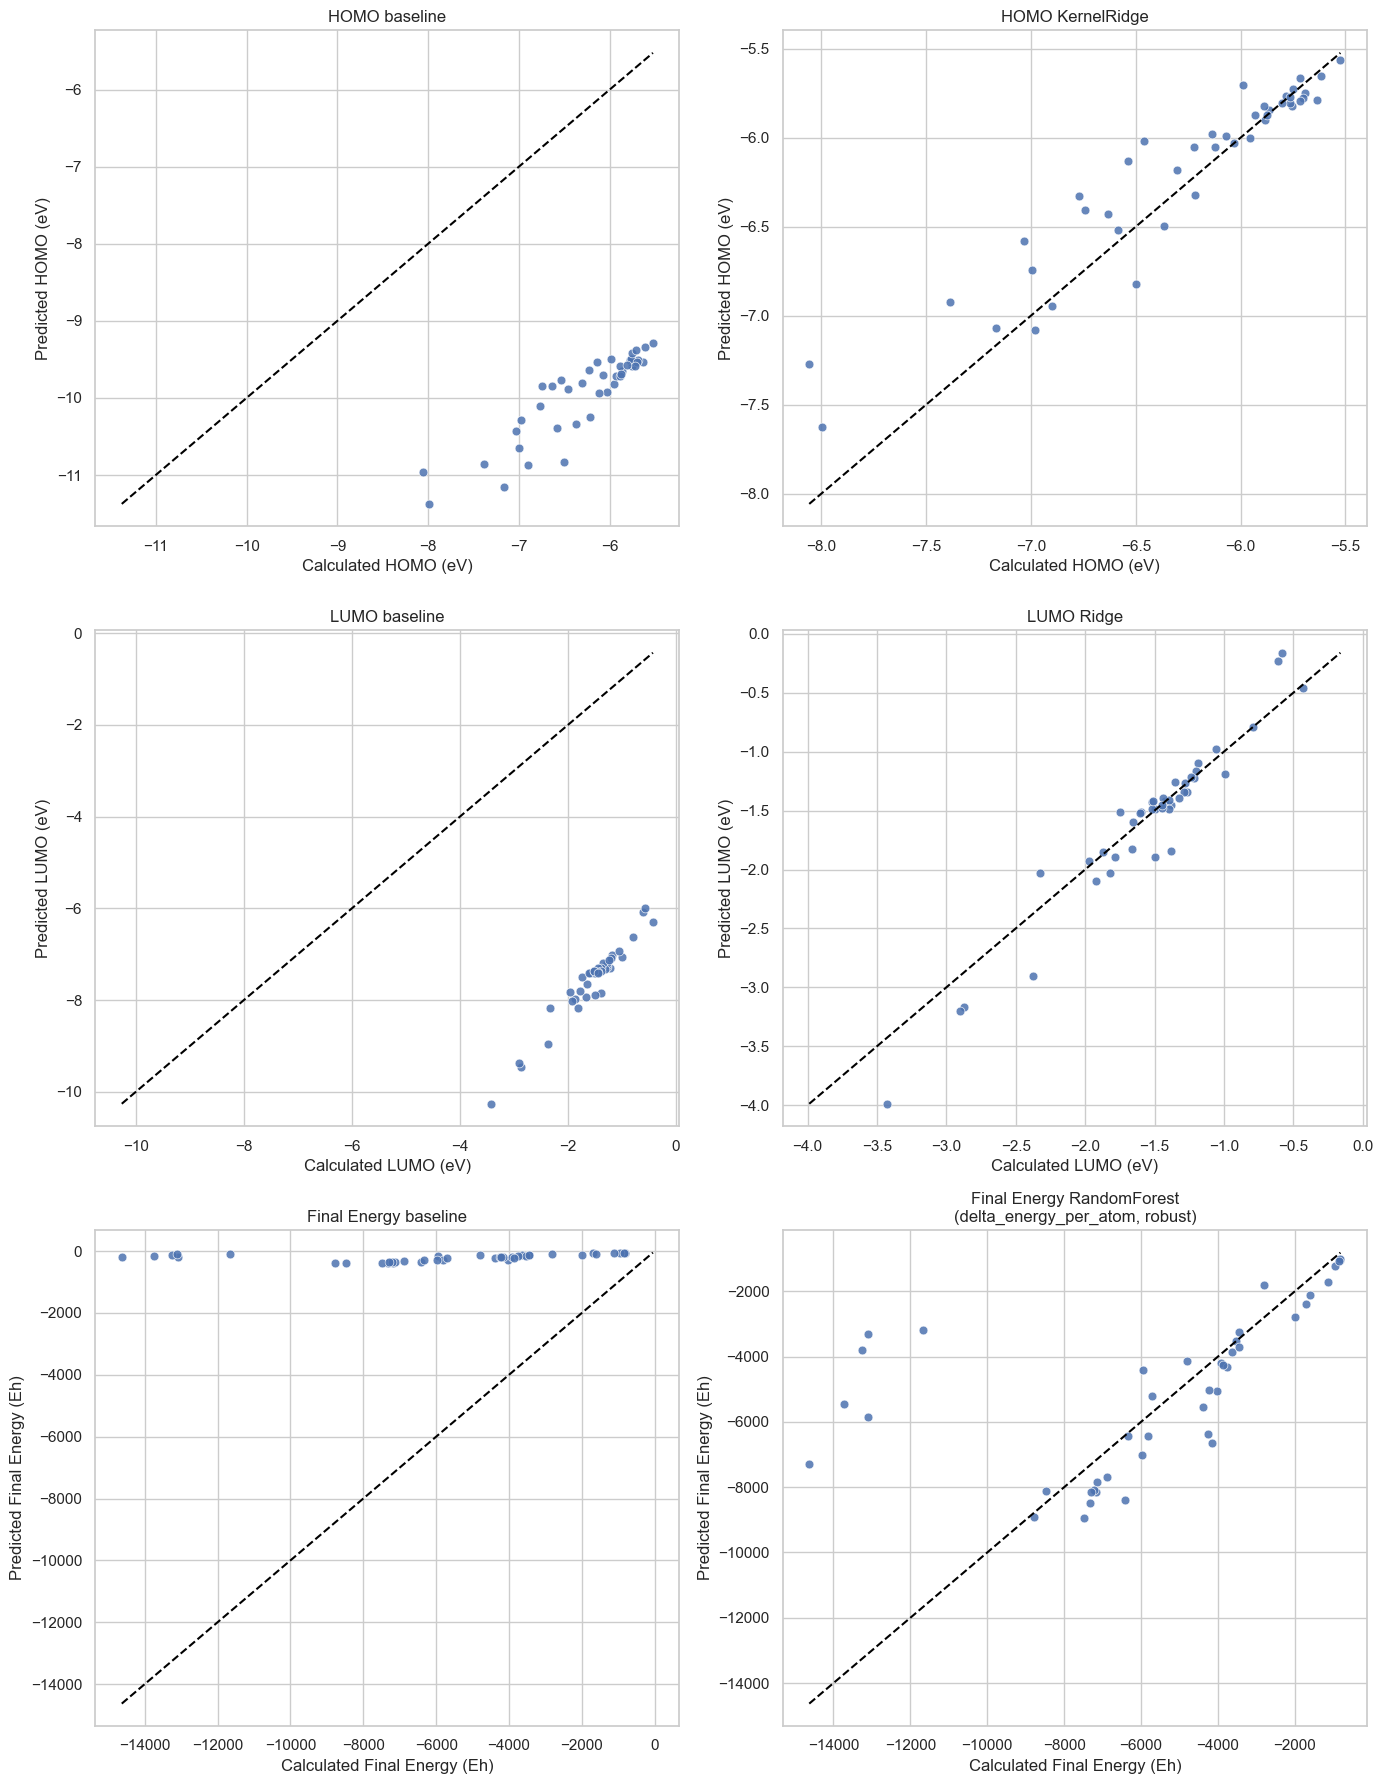

In [34]:
fig, axs = plt.subplots(3, 2, figsize=(14, 18))
axs = axs.flatten()

plot_data = [
    ("HOMO baseline", homo_true, homo_xtb, "Calculated HOMO (eV)", "Predicted HOMO (eV)"),
    (f"HOMO {selected_homo_model_name}", homo_true, homo_pred, "Calculated HOMO (eV)", "Predicted HOMO (eV)"),
    ("LUMO baseline", lumo_true, lumo_xtb, "Calculated LUMO (eV)", "Predicted LUMO (eV)"),
    (f"LUMO {selected_lumo_model_name}", lumo_true, lumo_pred, "Calculated LUMO (eV)", "Predicted LUMO (eV)"),
    ("Final Energy baseline", energy_true, energy_xtb, "Calculated Final Energy (Eh)", "Predicted Final Energy (Eh)"),
    (
        f"Final Energy {selected_energy_model_name}\n({selected_energy_target_mode}, {selected_energy_weight_scheme})",
        energy_true,
        energy_pred,
        "Calculated Final Energy (Eh)",
        "Predicted Final Energy (Eh)",
    ),
]

for i, (title, actual_vals, pred_vals, xlabel, ylabel) in enumerate(plot_data):
    ax = axs[i]
    sns.scatterplot(x=actual_vals, y=pred_vals, ax=ax, alpha=0.85, s=40)

    min_val = min(np.min(actual_vals), np.min(pred_vals))
    max_val = max(np.max(actual_vals), np.max(pred_vals))
    ax.plot([min_val, max_val], [min_val, max_val], "--", color="black")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "hybrid_model_parity_plots.png"), dpi=300, bbox_inches="tight")
plt.show()

## 7.1 Error distributions

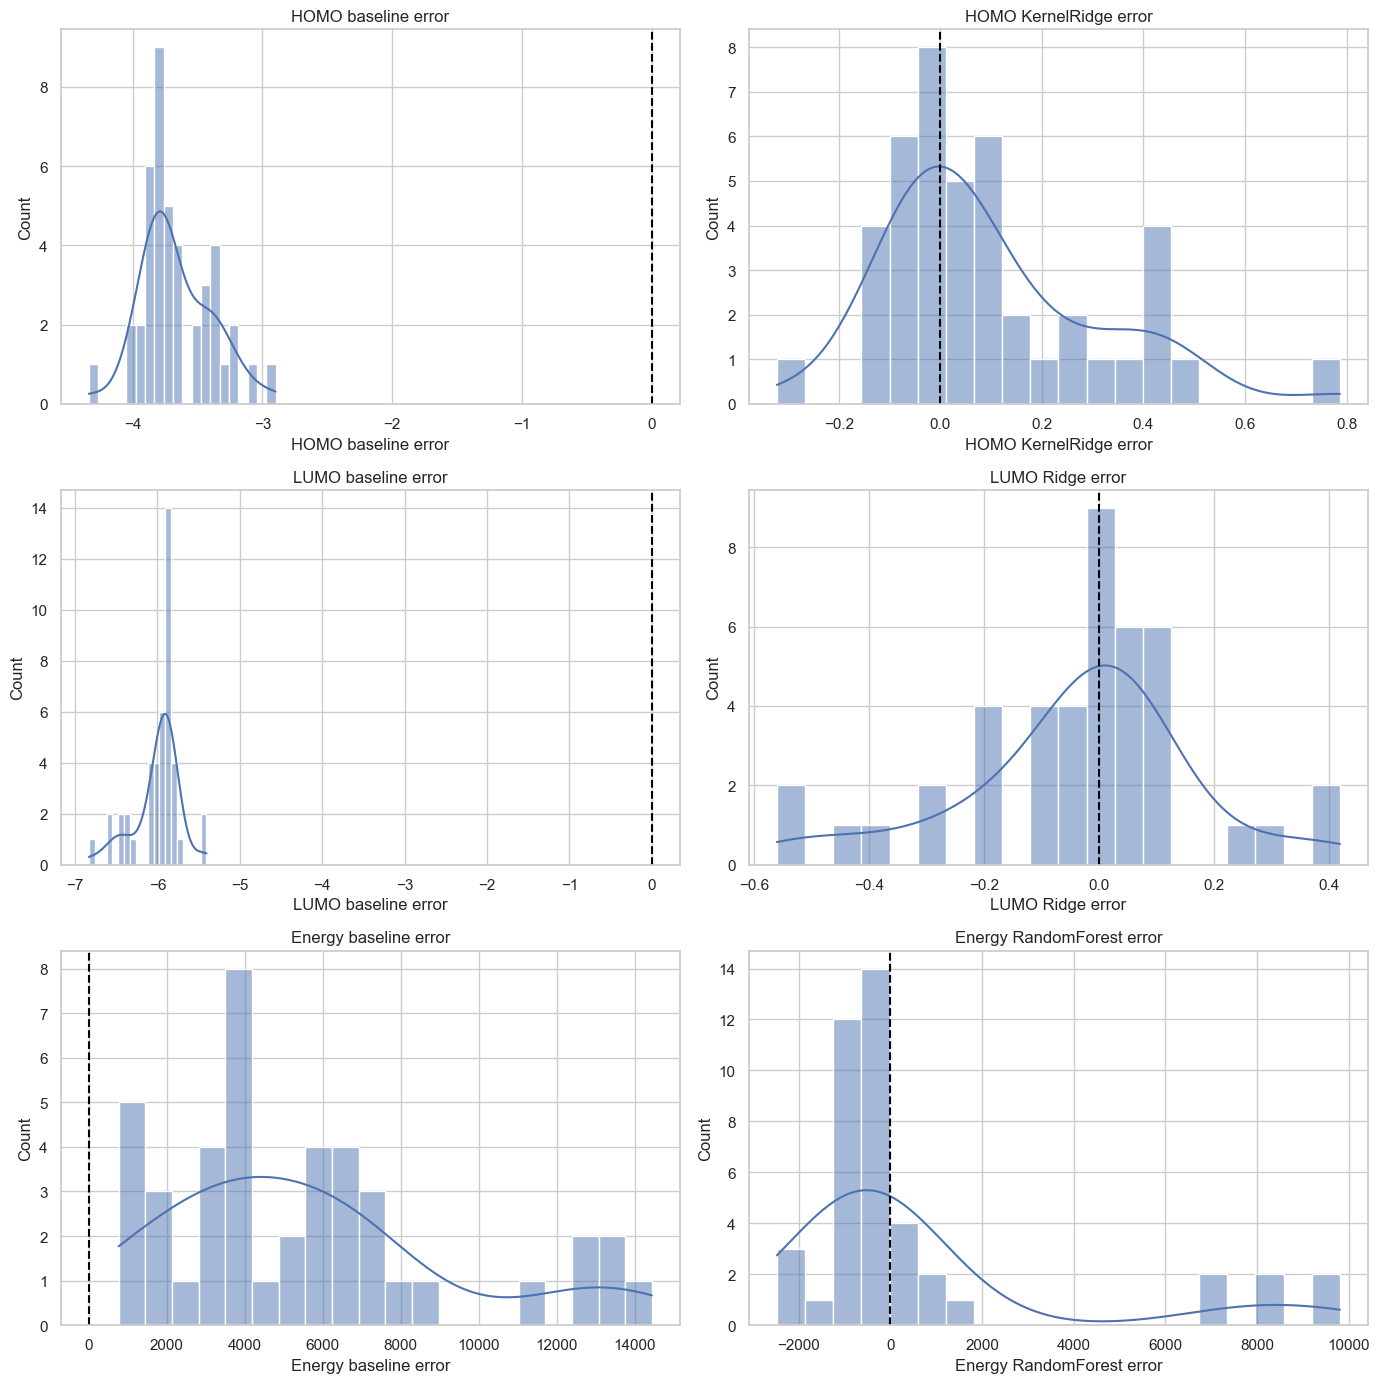

In [35]:
error_df = pd.DataFrame({
    "HOMO baseline error": homo_xtb - homo_true,
    f"HOMO {selected_homo_model_name} error": homo_pred - homo_true,
    "LUMO baseline error": lumo_xtb - lumo_true,
    f"LUMO {selected_lumo_model_name} error": lumo_pred - lumo_true,
    "Energy baseline error": energy_xtb - energy_true,
    f"Energy {selected_energy_model_name} error": energy_pred - energy_true,
})

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(error_df.columns):
    sns.histplot(error_df[col], bins=20, kde=True, ax=axes[i])
    axes[i].axvline(0, linestyle="--", color="black")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## 7.2 Residuals vs predictions

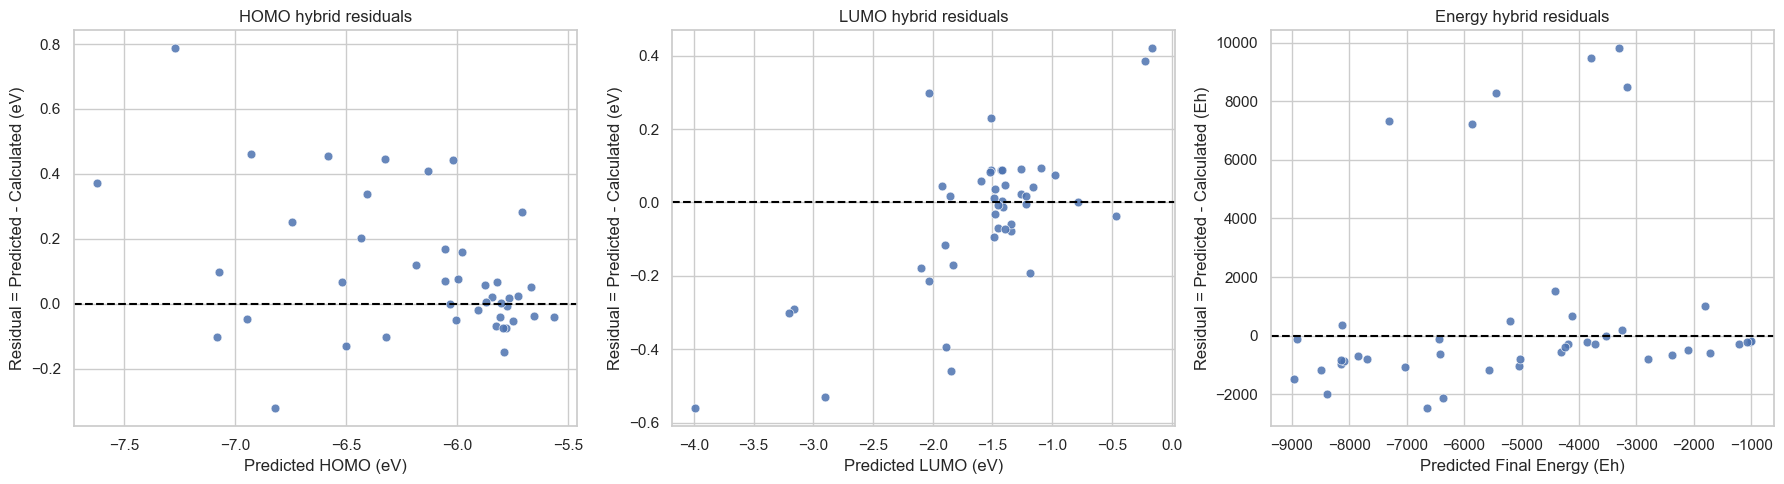

In [36]:
residual_plots = [
    ("HOMO hybrid residuals", homo_pred, homo_pred - homo_true, "Predicted HOMO (eV)", "Residual = Predicted - Calculated (eV)"),
    ("LUMO hybrid residuals", lumo_pred, lumo_pred - lumo_true, "Predicted LUMO (eV)", "Residual = Predicted - Calculated (eV)"),
    ("Energy hybrid residuals", energy_pred, energy_pred - energy_true, "Predicted Final Energy (Eh)", "Residual = Predicted - Calculated (Eh)"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, preds, residuals, xlabel, ylabel) in zip(axes, residual_plots):
    sns.scatterplot(x=preds, y=residuals, ax=ax, s=40, alpha=0.85)
    ax.axhline(0, linestyle="--", color="black")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.show()

# 8. Final full-dataset retraining for deployment

In [37]:
full_metadata_df = dataset[metadata_export_cols].copy().reset_index(drop=True)

full_inner_splits = make_group_folds(
    group_series=full_metadata_df["group_id"],
    n_splits=N_INNER_SPLITS,
    random_state=RANDOM_STATE + 90000
)

## HOMO model

In [38]:
deployment_homo_model, deployment_scaler_X_homo, deployment_scaler_y_homo, _, deployment_homo_params, deployment_homo_inner_score = fit_final_model(
    X_fit=X,
    y_fit=y_homo,
    X_eval=X,
    model_name=selected_homo_model_name,
    n_trials=MODEL_TRIALS[selected_homo_model_name],
    seed=RANDOM_STATE + 91000,
    inner_splits=full_inner_splits,
    weight_scheme_name=None
)

## LUMO model

In [39]:
deployment_lumo_model, deployment_scaler_X_lumo, deployment_scaler_y_lumo, _, deployment_lumo_params, deployment_lumo_inner_score = fit_final_model(
    X_fit=X,
    y_fit=y_lumo,
    X_eval=X,
    model_name=selected_lumo_model_name,
    n_trials=MODEL_TRIALS[selected_lumo_model_name],
    seed=RANDOM_STATE + 92000,
    inner_splits=full_inner_splits,
    weight_scheme_name=None
)

## Energy model

In [40]:
y_energy_full_selected = get_energy_target_for_indices(X.index, selected_energy_target_mode)

deployment_energy_model, deployment_scaler_X_energy, deployment_scaler_y_energy, _, deployment_energy_params, deployment_energy_inner_score = fit_final_model(
    X_fit=X,
    y_fit=y_energy_full_selected,
    X_eval=X,
    model_name=selected_energy_model_name,
    n_trials=MODEL_TRIALS[selected_energy_model_name],
    seed=RANDOM_STATE + 93000,
    inner_splits=full_inner_splits,
    weight_scheme_name=selected_energy_weight_scheme if selected_energy_model_name in WEIGHTED_MODELS else None,
    inner_score_fn=energy_inner_mae_from_restored(selected_energy_target_mode)
)

## Saving

In [41]:
deployment_homo_bundle = {
    "model_name": selected_homo_model_name,
    "target_name": "HOMO",
    "delta_target_name": "delta_homo",
    "feature_columns": features_common,
    "xtb_reference_column": "HOMO_xtb (eV)",
    "target_column": "HOMO_orca (eV)",
    "target_unit": "eV",
    "model": deployment_homo_model,
    "scaler_X": deployment_scaler_X_homo,
    "scaler_y": deployment_scaler_y_homo,
    "best_params": deployment_homo_params,
    "best_inner_score": deployment_homo_inner_score,
    "fit_scope": "full_dataset_after_holdout_evaluation",
}

deployment_lumo_bundle = {
    "model_name": selected_lumo_model_name,
    "target_name": "LUMO",
    "delta_target_name": "delta_lumo",
    "feature_columns": features_common,
    "xtb_reference_column": "LUMO_xtb (eV)",
    "target_column": "LUMO_orca (eV)",
    "target_unit": "eV",
    "model": deployment_lumo_model,
    "scaler_X": deployment_scaler_X_lumo,
    "scaler_y": deployment_scaler_y_lumo,
    "best_params": deployment_lumo_params,
    "best_inner_score": deployment_lumo_inner_score,
    "fit_scope": "full_dataset_after_holdout_evaluation",
}

deployment_energy_bundle = {
    "model_name": selected_energy_model_name,
    "target_name": "Final Energy",
    "feature_columns": features_common,
    "xtb_reference_column": "Total energy xtb (Eh)",
    "target_column": "Final Energy (Eh)",
    "target_unit": "Eh",
    "target_mode": selected_energy_target_mode,
    "weight_scheme_name": selected_energy_weight_scheme,
    "model": deployment_energy_model,
    "scaler_X": deployment_scaler_X_energy,
    "scaler_y": deployment_scaler_y_energy,
    "best_params": deployment_energy_params,
    "best_inner_score": deployment_energy_inner_score,
    "fit_scope": "full_dataset_after_holdout_evaluation",
}

In [42]:
joblib.dump(
    deployment_homo_bundle,
    os.path.join(OUTPUT_DIR, f"deployment_{selected_homo_model_name.lower()}_homo_bundle_all_data.pkl")
)

joblib.dump(
    deployment_lumo_bundle,
    os.path.join(OUTPUT_DIR, f"deployment_{selected_lumo_model_name.lower()}_lumo_bundle_all_data.pkl")
)

joblib.dump(
    deployment_energy_bundle,
    os.path.join(OUTPUT_DIR, f"deployment_{selected_energy_model_name.lower()}_energy_bundle_all_data.pkl")
)

['./output_final\\deployment_randomforest_energy_bundle_all_data.pkl']